# Data Preparation

## 1. Import Pustaka yang Dibutuhkan

In [131]:
# EDA & Visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Merge Dataset
from functools import reduce

# Resampling
from imblearn.combine import SMOTEENN
from collections import Counter

# Standarization
from sklearn.preprocessing import MinMaxScaler

# Splitting, Algorithms
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# Hyperparameter
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, average_precision_score
from sklearn.metrics import roc_auc_score, roc_curve

# Feature importance
import eli5
from eli5.sklearn import PermutationImportance

# Export model
import pickle

## 2. Import Dataset

In [132]:
# Demographics Data
demo_DE = pd.read_csv('../data/Demographics Data/DEMO_L.csv', na_values=' ')
# Examination Data
bp_E = pd.read_csv('../data/Examination Data/BPXO_L.csv', na_values=' ')
body_E = pd.read_csv('../data/Examination Data/BMX_L.csv', na_values=' ')
# Laboratory Data
glyco_L = pd.read_csv('../data/Laboratory Data/GHB_L.csv', na_values=' ')
tchol_L = pd.read_csv('../data/Laboratory Data/TCHOL_L.csv', na_values=' ')
# Questionnaire Data
alcohol_Q = pd.read_csv('../data/Questionnaire Data/ALQ_L.csv', na_values=' ')
bpcl_Q = pd.read_csv('../data/Questionnaire Data/BPQ_L.csv', na_values=' ')
diabetes_Q = pd.read_csv('../data/Questionnaire Data/DIQ_L.csv', na_values=' ')
depress_Q = pd.read_csv('../data/Questionnaire Data/DPQ_L.csv', na_values=' ')
medic_Q= pd.read_csv('../data/Questionnaire Data/MCQ_L.csv', na_values=' ')
smoke_Q = pd.read_csv('../data/Questionnaire Data/SMQ_L.csv', na_values=' ')

## 3. Gabung Dataset

In [133]:
df_list =[
    demo_DE, bp_E, body_E, glyco_L, tchol_L, alcohol_Q, 
    bpcl_Q, diabetes_Q, depress_Q, medic_Q, smoke_Q
]
final_df = reduce(lambda df1, df2: pd.merge(df1, df2, on='SEQN', how='outer'), df_list)

In [134]:
final_df.shape

(11933, 137)

In [135]:
final_df.head()

,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,MCQ230D,OSQ230,SMQ020,SMQ040,SMD641,SMD650,SMD100MN,SMQ621,SMD630,SMAQUEX2
0,130378.0,12.0,2.0,1.0,43.0,NaN,5.0,6.0,2.0,NaN,...,NaN,2.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0
1,130379.0,12.0,2.0,1.0,66.0,NaN,3.0,3.0,2.0,NaN,...,NaN,1.0,1.0,3.0,NaN,NaN,NaN,NaN,NaN,1.0
2,130380.0,12.0,2.0,2.0,44.0,NaN,2.0,2.0,1.0,NaN,...,NaN,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,130381.0,12.0,2.0,2.0,5.0,NaN,5.0,7.0,1.0,71.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,130382.0,12.0,2.0,1.0,2.0,NaN,3.0,3.0,2.0,34.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Saring Fitur yang Akan Digunakan

Terdapat 5 kelompok data yaitu Demographics Data, Examination Data, Laboratory Data, Questionnaire Data. Setiap kelompok data memiliki berbagai jenis dataset yang berhubungan berdasarkan kelompok terkait, kecuali Demographics Data yang hanya memiliki satu dataset. Dataset-dataset yang berada dalam kelompok tersebut akan dipilih, di dalamnya akan diambil beberapa kolom untuk membentuk dataset baru. Sumber data bisa diakses [disini](https://wwwn.cdc.gov/nchs/nhanes/continuousnhanes/default.aspx?Cycle=2021-2023). Untuk filter/pemilihan kolom dalam setiap datasetnya dapat dilihat sebagai berikut.

Demographics Data:
- DEMO_L: Demographic Variables and Sample Weights
    - RIAGENDR - Gender
    - RIDAGEYR - Age in years at screening
    - RIDRETH3 - Race/Hispanic origin w/ NH Asian</br>
    
Examination Data:
- BPXO_L: Blood Pressure - Oscillometric Measurements
    - BPXOSY1 - Systolic - 1st oscillometric reading
    - BPXODI1 - Diastolic - 1st oscillometric reading
    - BPXOSY2 - Systolic - 2nd oscillometric reading
    - BPXODI2 - Diastolic - 2nd oscillometric reading
    - BPXOSY3 - Systolic - 3rd oscillometric reading
    - BPXODI3 - Diastolic - 3rd oscillometric reading
- BMX_L: Body Measures
    - BMXBMI - Body Mass Index (kg/m**2)</br>
    
Laboratory Data:
- GHB_L: Glycohemoglobin
    - LBXGH - Glycohemoglobin (%)
- TCHOL_L: Cholesterol - Total
    - LBXTC - Total Cholesterol (mg/dL)</br>
    
Questionnaire Data:
- ALQ_L: Alcohol Use
    - ALQ121 - 'Past 12 mos how often drink alc bev' (alkohol)
- BPQ_L: Blood Pressure & Cholesterol
    - BPQ080 - Doctor told you - high cholesterol level
- DIQ_L: Diabetes
    - DIQ010 - 'Doctor told you have diabetes' (diabetes)
- DPQ_L: Mental Health - Depression Screener
    - DPQ020 - Feeling down, depressed, or hopeless
    - DPQ030 - Trouble sleeping or sleeping too much
    - DPQ050 - Poor appetite or overeating
- MCQ_L: Medical Conditions
    - MCQ160l - Ever told you had any liver condition
    - MCQ160m - Ever told you had thyroid problem
    - MCQ220 - Ever told you had cancer or malignancy
- SMQ_L: Smoking - Cigarette Use
    - SMQ020 - 'Smoked at least 100 cigarettes in life' (merokok_100)

---

Kategori Faktor Risiko:
- Demografi:
    - Umur
    - Jenis Kelamin
    - Ras

    </br>
- Pemeriksaan Medis:
    - Systolic - 1st oscillometric reading
    - Diastolic - 1st oscillometric reading
    - Systolic - 2nd oscillometric reading
    - Diastolic - 2nd oscillometric reading
    - Systolic - 3rd oscillometric reading
    - Diastolic - 3rd oscillometric reading
    - BMI
    - HbA1c
    - Kadar Kolesterol

    </br>
- Kesehatan Mental:
    - Sedih, Depersi, atau Putus Asa
    - Gangguan Tidur
    - Kelelahan
    - Gannguan Makan

    </br>
- Riwayat Medis:
    - Kolesterol Tinggi
    - Tiroid
    - Liver
    - Kanker

    </br>
- Gaya Hidup:
    - Konsumsi Alkohol
    - Merokok

In [136]:
# saring fitur dengan memasukkan fitur yang akan digunakan
# ke dalam satu dataset bernama df

# Column Subsetting
df = final_df[[
    'SEQN', # fitur identifikasi
    'RIAGENDR','RIDAGEYR','RIDRETH3',
    'BPXOSY1','BPXODI1','BPXOSY2','BPXODI2','BPXOSY3','BPXODI3',
    'BMXBMI',
    'LBXGH',
    'LBXTC',
    'ALQ121',
    'BPQ080',
    'DIQ010',
    'DPQ020','DPQ030','DPQ050',
    'MCQ160L','MCQ160M','MCQ220',
    'SMQ020'
]]

In [137]:
df.shape

(11933, 23)

## 5. Drop Nilai Null

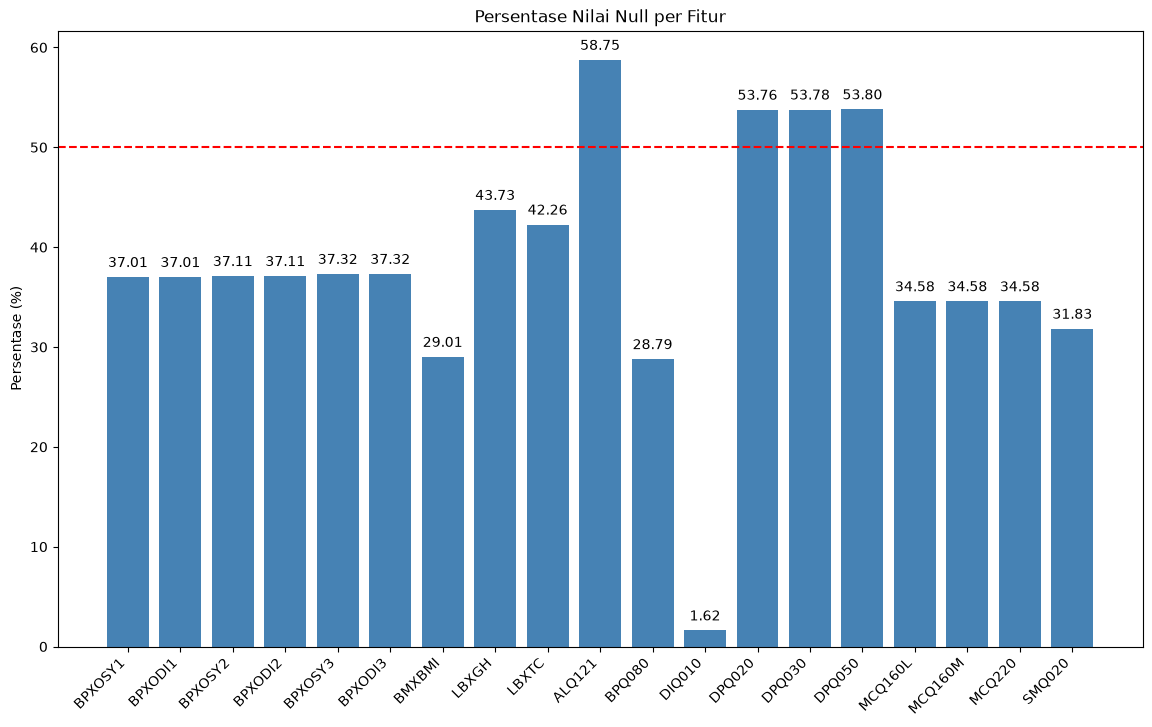

In [138]:
# Hitung jumlah nilai null per fitur
null_counts = df.isnull().sum()

# Hitung persentase null per fitur
null_percent = (null_counts / len(df)) * 100

# Ambil hanya fitur yang memiliki null
null_percent = null_percent[null_percent > 0]

# Plot
plt.figure(figsize=(14, 8))
bars = plt.bar(null_percent.index, null_percent.values, color='steelblue')
# Tambahkan nilai persentase di atas tiap bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 1,
             f'{height:.2f}', ha='center', fontsize=10)
# Garis horizontal putus-putus di 50%
plt.axhline(y=50, color='red', linestyle='--', linewidth=1.5)
# Label dan tampilan
plt.xticks(rotation=45, ha='right')
plt.ylabel('Persentase (%)')
plt.title('Persentase Nilai Null per Fitur')
plt.show()

In [139]:
# lihat jumlah Null tiap fitur
df.isnull().sum()

SEQN           0
RIAGENDR       0
RIDAGEYR       0
RIDRETH3       0
BPXOSY1     4416
BPXODI1     4416
BPXOSY2     4428
BPXODI2     4428
BPXOSY3     4453
BPXODI3     4453
BMXBMI      3462
LBXGH       5218
LBXTC       5043
ALQ121      7011
BPQ080      3435
DIQ010       193
DPQ020      6415
DPQ030      6417
DPQ050      6420
MCQ160L     4126
MCQ160M     4127
MCQ220      4126
SMQ020      3798
dtype: int64

In [140]:
# drop nilai null dengan fungsi dropna()
df = df.dropna(ignore_index=True)

In [141]:
# dimensi dataset setelah Null dihilangkan
df.shape

(4268, 23)

## 6. Drop Fitur Identifikasi (SEQN)

In [142]:
# drop fitur identifikasi
df = df.drop(columns='SEQN')

## 7. Menetapkan Tipe Data Fitur

In [143]:
# lihat tipe data tiap fitur
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4268 entries, 0 to 4267
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   RIAGENDR  4268 non-null   float64
 1   RIDAGEYR  4268 non-null   float64
 2   RIDRETH3  4268 non-null   float64
 3   BPXOSY1   4268 non-null   float64
 4   BPXODI1   4268 non-null   float64
 5   BPXOSY2   4268 non-null   float64
 6   BPXODI2   4268 non-null   float64
 7   BPXOSY3   4268 non-null   float64
 8   BPXODI3   4268 non-null   float64
 9   BMXBMI    4268 non-null   float64
 10  LBXGH     4268 non-null   float64
 11  LBXTC     4268 non-null   float64
 12  ALQ121    4268 non-null   float64
 13  BPQ080    4268 non-null   float64
 14  DIQ010    4268 non-null   float64
 15  DPQ020    4268 non-null   float64
 16  DPQ030    4268 non-null   float64
 17  DPQ050    4268 non-null   float64
 18  MCQ160L   4268 non-null   float64
 19  MCQ160M   4268 non-null   float64
 20  MCQ220    4268 non-null   float64
 21  SM

In [144]:
# 1. Fitur numerik dengan 'int64'
# 2. Fitur katagori dengan 'category'
# 3. Fitur numerik non-integer diubah dengan 'float64'
# 4. Semua fitur otomatis bertipe float setelah proses import,
# sehingga fitur katagori yang semuanya bernilai angka/numerik perlu
# dibulatkan terlebih dahulu dengan int64 sebelum diubah ke dalam fitur
# kategori.

# Demographic Variables and Sample Weights
df['RIAGENDR'] = df['RIAGENDR'].astype('int64').astype('category')
df['RIDAGEYR'] = df['RIDAGEYR'].astype('int64')
df['RIDRETH3'] = df['RIDRETH3'].astype('int64').astype('category')
# Blood Pressure - Oscillometric Measurements
df['BPXOSY1'] = df['BPXOSY1'].astype('int64')
df['BPXODI1'] = df['BPXODI1'].astype('int64')
df['BPXOSY2'] = df['BPXOSY2'].astype('int64')
df['BPXODI2'] = df['BPXODI2'].astype('int64')
df['BPXOSY3'] = df['BPXOSY3'].astype('int64')
df['BPXODI3'] = df['BPXODI3'].astype('int64')
# Body Measures
df['BMXBMI'] = df['BMXBMI'].astype('float64')
# Glycohemoglobin
df['LBXGH'] = df['LBXGH'].astype('float64')
# Cholesterol – Total
df['LBXTC'] = df['LBXTC'].astype('int64')
# Alcohol Use
df['ALQ121'] = df['ALQ121'].astype('int64').astype('category')
# Blood Pressure & Cholesterol
df['BPQ080'] = df['BPQ080'].astype('int64').astype('category')
# Diabetes
df['DIQ010'] = df['DIQ010'].astype('int64').astype('category')
# Mental Health - Depression Screener
df['DPQ020'] = df['DPQ020'].astype('int64').astype('category')
df['DPQ030'] = df['DPQ030'].astype('int64').astype('category')
df['DPQ050'] = df['DPQ050'].astype('int64').astype('category')
# Medical Conditions
df['MCQ160L'] = df['MCQ160L'].astype('int64').astype('category')
df['MCQ160M'] = df['MCQ160M'].astype('int64').astype('category')
df['MCQ220'] = df['MCQ220'].astype('int64').astype('category')
# Smoking - Cigarette Use
df['SMQ020'] = df['SMQ020'].astype('int64').astype('category')

In [145]:
# lihat tipe data tiap fitur setelah konversi
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4268 entries, 0 to 4267
Data columns (total 22 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   RIAGENDR  4268 non-null   category
 1   RIDAGEYR  4268 non-null   int64   
 2   RIDRETH3  4268 non-null   category
 3   BPXOSY1   4268 non-null   int64   
 4   BPXODI1   4268 non-null   int64   
 5   BPXOSY2   4268 non-null   int64   
 6   BPXODI2   4268 non-null   int64   
 7   BPXOSY3   4268 non-null   int64   
 8   BPXODI3   4268 non-null   int64   
 9   BMXBMI    4268 non-null   float64 
 10  LBXGH     4268 non-null   float64 
 11  LBXTC     4268 non-null   int64   
 12  ALQ121    4268 non-null   category
 13  BPQ080    4268 non-null   category
 14  DIQ010    4268 non-null   category
 15  DPQ020    4268 non-null   category
 16  DPQ030    4268 non-null   category
 17  DPQ050    4268 non-null   category
 18  MCQ160L   4268 non-null   category
 19  MCQ160M   4268 non-null   category
 20  MCQ220    4268 non-

## 8. Mengubah Nama Fitur

In [146]:
# Mengubah nama fitur agar lebih komunikatif dengan fungsi rename()
df = df.rename(columns={
    # Data Demografi
    'RIAGENDR':'gender','RIDAGEYR':'usia','RIDRETH3':'ras',
    # Pemeriksaan Medis
    'BPXOSY1':'sistolik1','BPXOSY2':'sistolik2','BPXOSY3':'sistolik3',
    'BPXODI1':'diastolik1','BPXODI2':'diastolik2','BPXODI3':'diastolik3',
    'BMXBMI':'BMI', 'LBXGH':'HbA1c', 'LBXTC':'kadar_kolesterol', 
    # Riwayat Kesehatan
    'BPQ080':'riw_kolesterol_tinggi', 'MCQ160L':'riw_liver',
    'MCQ160M':'riw_tiroid','MCQ220':'riw_kanker',
    # Kesehatan Mental
    'DPQ020':'sedih-depresi-putus_asa','DPQ030':'gangguan_tidur','DPQ050':'gangguan_makan',
    # Gaya Hidup
    'ALQ121':'alkohol','SMQ020':'merokok100',
    # Target
    'DIQ010':'diabetes'
})

In [147]:
df.head()

,gender,usia,ras,sistolik1,diastolik1,sistolik2,diastolik2,sistolik3,diastolik3,BMI,...,alkohol,riw_kolesterol_tinggi,diabetes,sedih-depresi-putus_asa,gangguan_tidur,gangguan_makan,riw_liver,riw_tiroid,riw_kanker,merokok100
0,1,66,3,121,84,117,76,113,76,33.5,...,2,2,2,0,1,0,2,2,1,1
1,2,44,2,111,79,112,80,104,76,29.7,...,10,1,1,0,1,0,2,1,2,2
2,1,34,1,110,72,120,74,115,75,30.2,...,4,2,2,0,0,0,2,2,2,1
3,2,68,3,143,76,136,74,145,78,42.6,...,0,1,2,0,0,0,2,2,1,2
4,2,74,3,154,76,167,70,154,68,43.0,...,8,2,2,0,0,0,2,1,1,2


# Exploratory Data Analysis

In [148]:
# membuat list nama fitur numerik dan fitur katagori 
# agar memudahkan visualisasi data

In [149]:
num_cols = ['usia', 'sistolik1', 'diastolik1', 'sistolik2', 'diastolik2', 'sistolik3', 'diastolik3', 'BMI', 'HbA1c', 'kadar_kolesterol']

In [150]:
len(num_cols)

10

In [151]:
cat_cols = ['gender', 'ras', 'alkohol','sedih-depresi-putus_asa','gangguan_tidur', 'gangguan_makan', 'riw_liver', 'riw_tiroid', 'riw_kanker','riw_kolesterol_tinggi', 'merokok100']

In [152]:
len(cat_cols)

11

In [153]:
all_cols = num_cols + cat_cols

## 1. Statistik Deskriptif

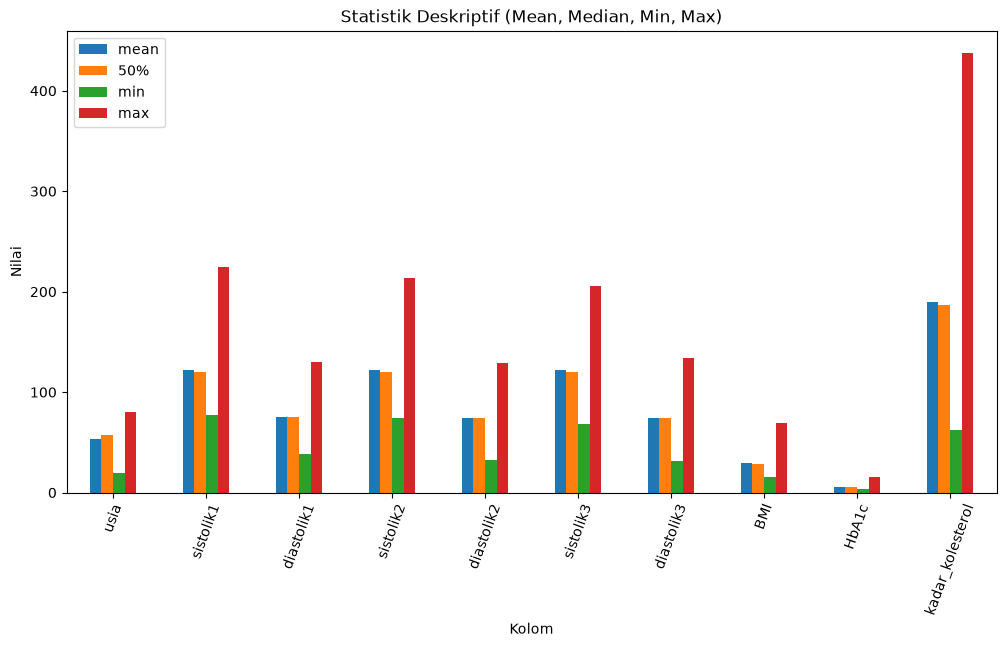

In [154]:
stats = df[num_cols].describe().loc[['mean', '50%', 'min', 'max']]
stats.T.plot(kind='bar', figsize=(12, 6))
plt.title('Statistik Deskriptif (Mean, Median, Min, Max)')
plt.ylabel('Nilai')
plt.xlabel('Kolom')
plt.xticks(rotation=70)
plt.legend(loc='upper left')
plt.show()

## 2. Fitur Numerik

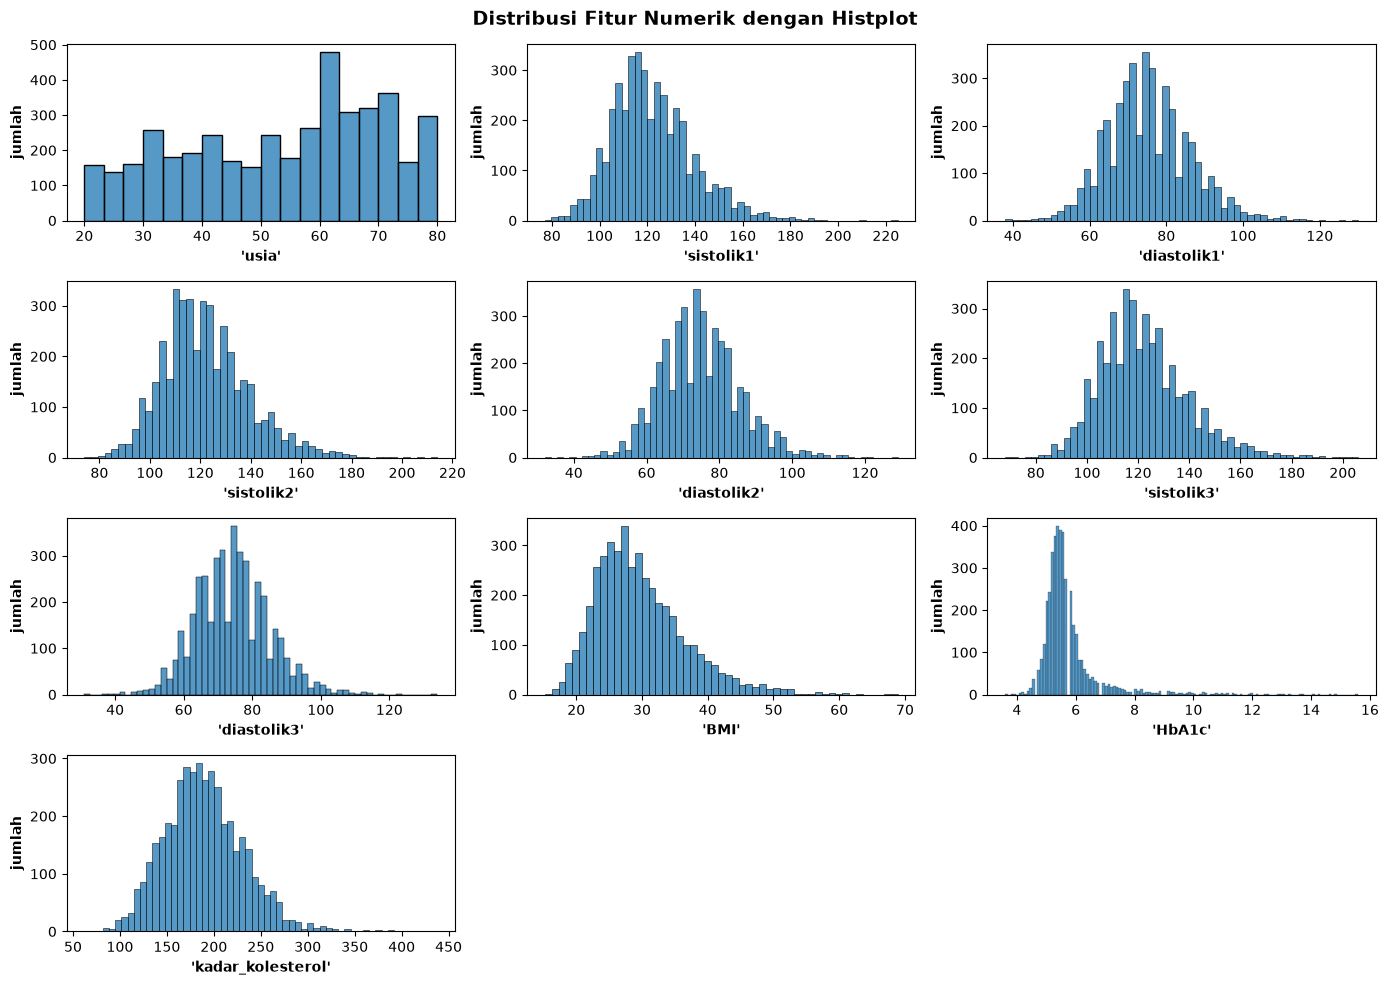

In [155]:
fig, ax = plt.subplots(4, 3, figsize=(14, 10))
ax = ax.flatten()
plt.suptitle("Distribusi Fitur Numerik dengan Histplot", fontsize=14, fontweight='bold')

for col, index in zip(num_cols, range(len(num_cols))):
    sns.histplot(ax=ax[num_cols.index(col)], x=col, data=df, log_scale=False)
    ax[num_cols.index(col)].set_xlabel(f"'{col}'", fontsize=10, fontweight='bold')
    ax[num_cols.index(col)].set_ylabel("jumlah", fontsize=10, fontweight='bold')
    # ax[num_cols.index(col)].set_yticks()

ax[len(num_cols)].set_axis_off()
ax[len(num_cols)+1].set_axis_off()
plt.tight_layout()
plt.show()

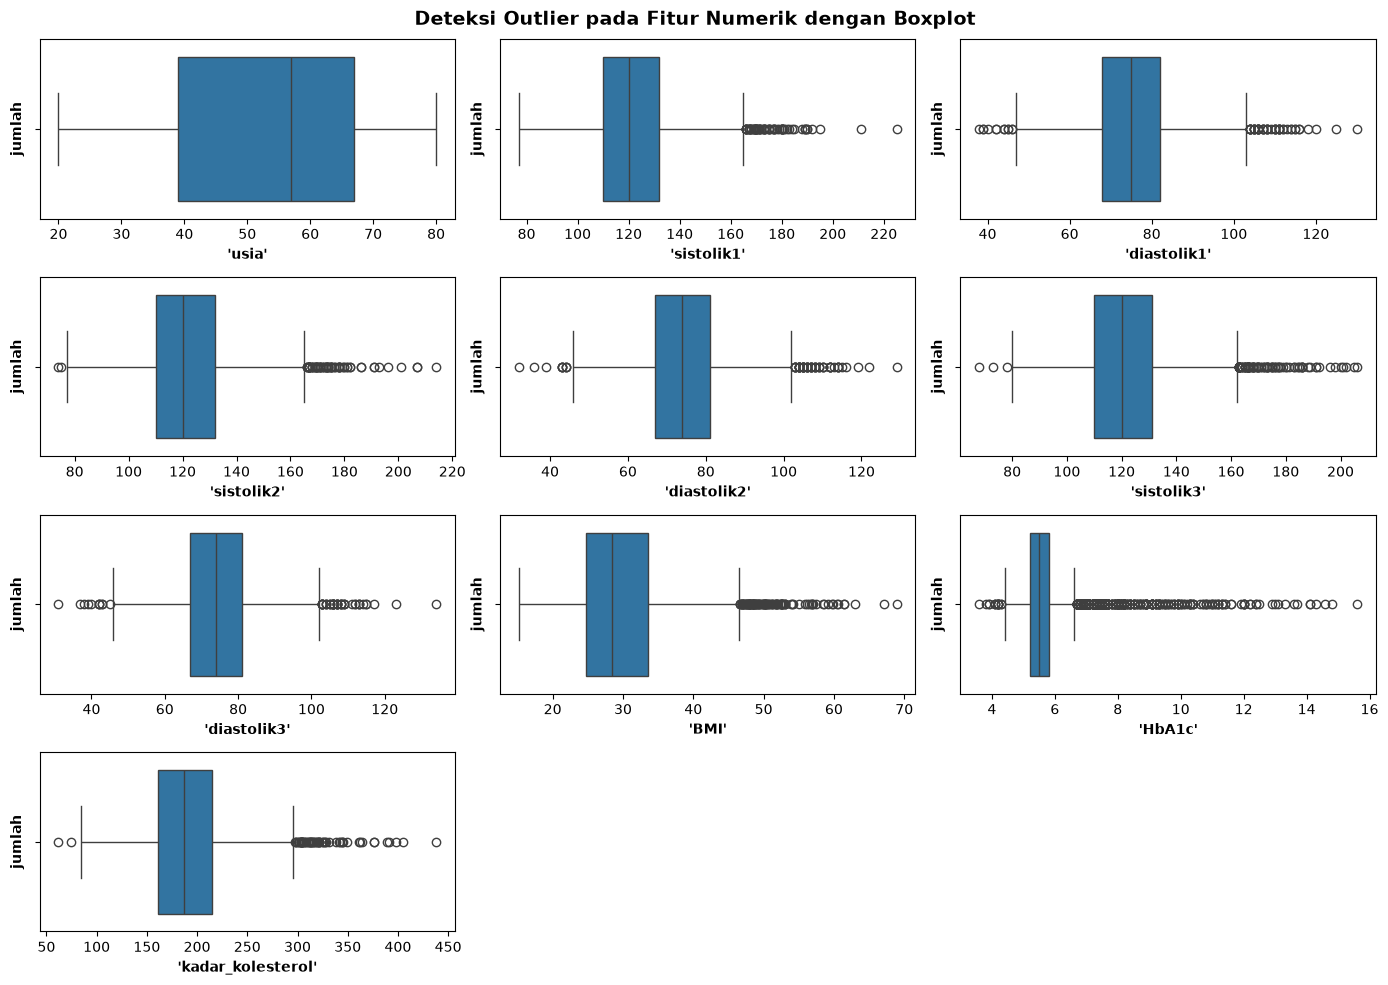

In [156]:
fig, ax = plt.subplots(4, 3, figsize=(14, 10))
ax = ax.flatten()
plt.suptitle("Deteksi Outlier pada Fitur Numerik dengan Boxplot", fontsize=14, fontweight='bold')

for col, index in zip(num_cols, range(len(num_cols))):
    sns.boxplot(ax=ax[num_cols.index(col)], x=col, data=df)
    ax[num_cols.index(col)].set_xlabel(f"'{col}'", fontsize=10, fontweight='bold')
    ax[num_cols.index(col)].set_ylabel("jumlah", fontsize=10, fontweight='bold')

ax[len(num_cols)].set_axis_off()
ax[len(num_cols)+1].set_axis_off()
plt.tight_layout()
plt.show()

## 3. Fitur Katagorikal

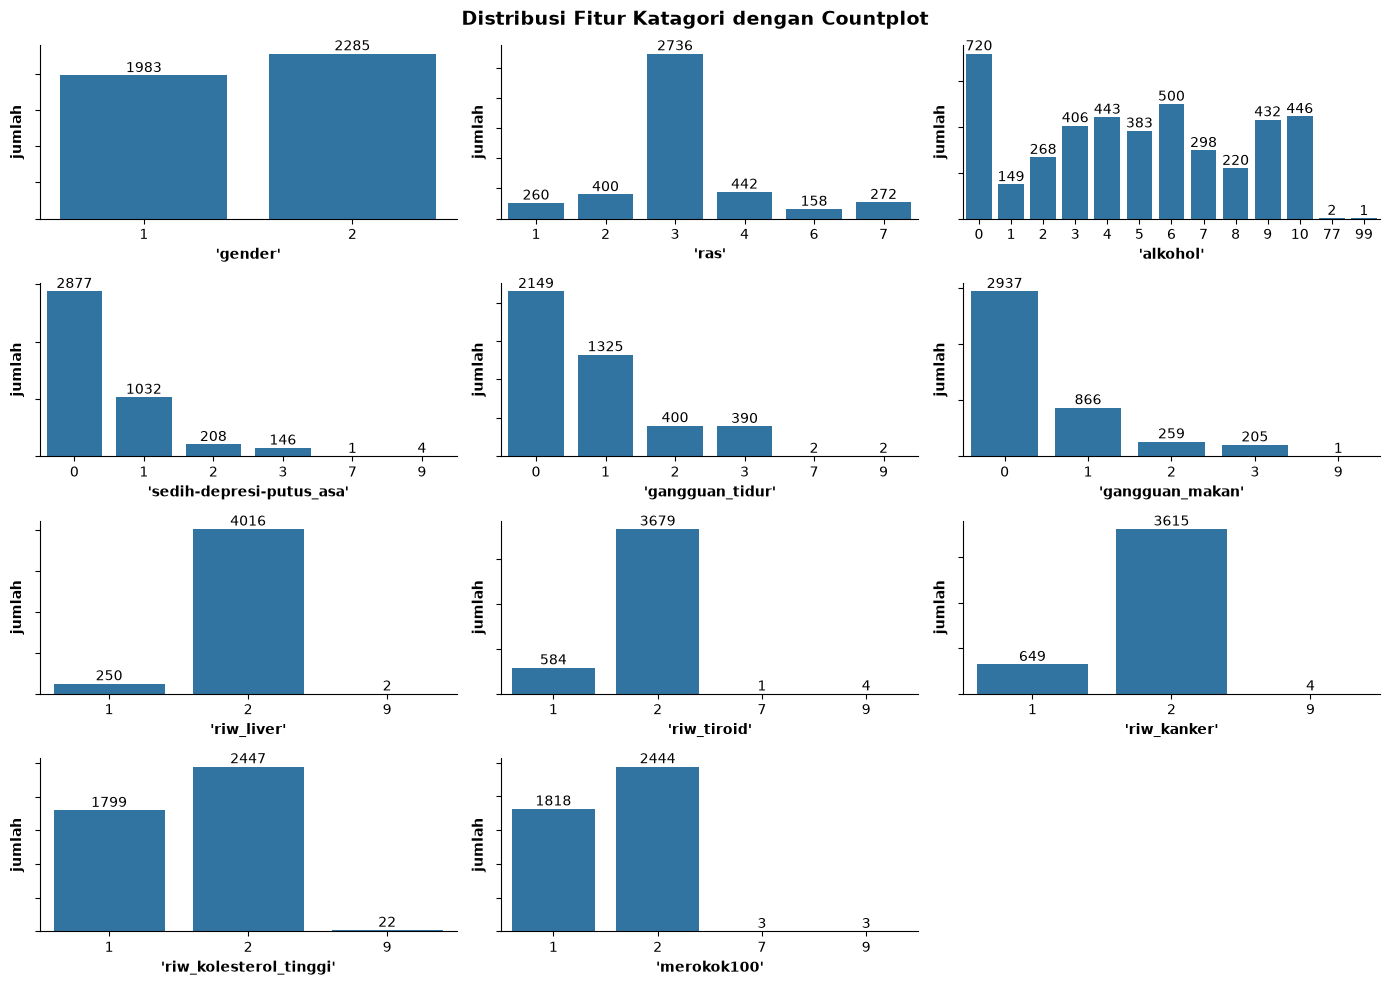

In [157]:
fig, ax = plt.subplots(4, 3, figsize=(14, 10))
ax = ax.flatten()
plt.suptitle("Distribusi Fitur Katagori dengan Countplot", fontsize=14, fontweight='bold')

for col, index in zip(cat_cols, range(len(cat_cols))):
    sns.countplot(ax=ax[cat_cols.index(col)], x=col, data=df)
    ax[cat_cols.index(col)].set_ylabel("jumlah", fontsize=10, fontweight='bold')
    ax[cat_cols.index(col)].set_xlabel(f"'{col}'", fontsize=10, fontweight='bold')
    ax[cat_cols.index(col)].bar_label(ax[cat_cols.index(col)].containers[0])
    ax[cat_cols.index(col)].spines['right'].set_visible(False)
    ax[cat_cols.index(col)].spines['top'].set_visible(False)
    ax[cat_cols.index(col)].set_yticklabels([])
# ax[len(num_cols)].set_axis_off()
ax[len(num_cols)+1].set_axis_off()
plt.tight_layout()
plt.show()

## 4. Korelasi Fitur

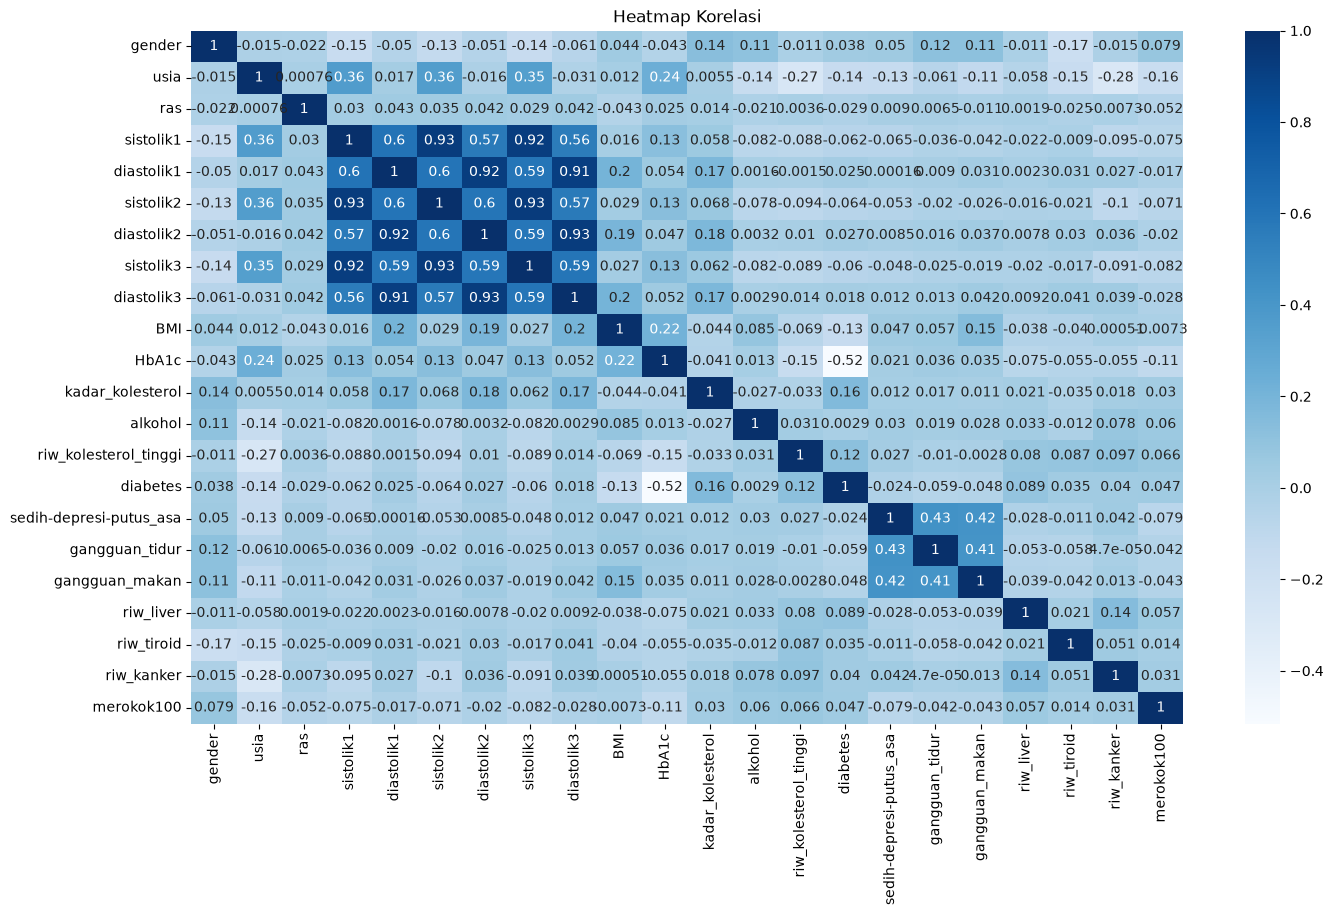

In [158]:
plt.figure(figsize=(16, 9))
sns.heatmap(df.corr(), annot=True, cmap='Blues')
plt.title('Heatmap Korelasi')
plt.xticks(rotation=90)
plt.show()

## 5. Data Target

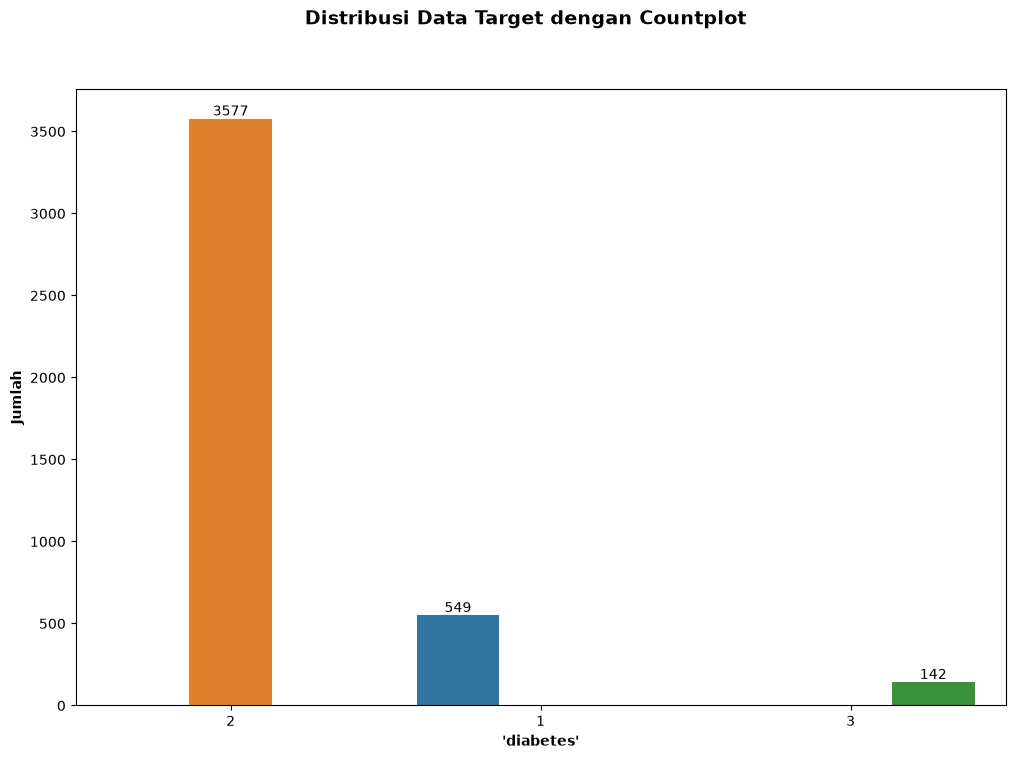

In [159]:
fig, ax = plt.subplots(figsize=(12, 8))
plt.suptitle("Distribusi Data Target dengan Countplot", fontsize=14, fontweight='bold')

sns.countplot(data=df, x='diabetes', hue='diabetes', order=df['diabetes'].value_counts().index, legend=False)
ax.set_xlabel("'diabetes'", fontsize=10, fontweight='bold')
ax.set_ylabel("Jumlah", fontsize=10, fontweight='bold')
for i in range(len(df['diabetes'].value_counts())):
    ax.bar_label(ax.containers[i-1])
ax.set_xticks(range(len(df['diabetes'].value_counts())))
plt.show()

# Data Preprocessing

## 1. Drop Respon Tidak Pasti

Drop respon yang tidak pasti
- Kolom `alkohol` yang bernilai 99 artinya responden menjawab tidak tahu, 77 artinya reponden menolak menjawab
- Kolom `sedih/depresi/putus_asa` yang bernilai 7 artinya responden menolak menjawab, 9 artinya responden menjawab tidak tahu
- Kolom `gangguan_tidur` yang bernilai 7 artinya responden menolak menjawab, 9 artinya responden menjawab tidak tahu
- Kolom `gangguan_makan` yang bernilai 7 artinya responden menolak menjawab, 9 artinya responden menjawab tidak tahu
- Kolom `tiroid` yang bernilai 7 artinya responden menolak menjawab, 9 artinya responden menjawab tidak tahu
- Kolom `kanker` yang bernilai 7 artinya responden menolak menjawab, 9 artinya responden menjawab tidak tahu
- Kolom `merokok100` yang bernilai 7 artinya responden menolak menjawab, 9 artinya responden menjawab tidak tahu
- Kolom `akt_fisik` yang bernilai 7777 artinya responden menolak menjawab, 9999 artinya responden menjawab tidak tahu
- Kolom `riw_darah_tinggi` yang bernilai 7 artinya responden menolak menjawab, 9 artinya responden menjawab tidak tahu
- Kolom `riw_kolesterol_tinggi` yang bernilai 7 artinya responden menolak menjawab, 9 artinya responden menjawab tidak tahu
- Kolom `diabetes` yang bernilai 3 artinya responden prediabetes, sedangkan prediksi hanya akan menentukan positif atau negatif saja

In [160]:
print(f"Dimensi dataset sebelum di drop{df.shape}")

Dimensi dataset sebelum di drop(4268, 22)


In [161]:
columns_to_filter = {
    # katagori
    'diabetes': [3],
    'alkohol': [99, 77],
    'sedih-depresi-putus_asa': [9, 7],
    'gangguan_tidur': [9, 7],
    'gangguan_makan': [9, 7],
    'riw_liver': [9, 7],
    'riw_tiroid': [9, 7],
    'riw_kanker': [9, 7],
    'riw_kolesterol_tinggi': [9, 7],
    'merokok100': [9, 7]
}
for col, values in columns_to_filter.items():
    if pd.api.types.is_numeric_dtype(df[col]):
        df = df.loc[~df[col].isin(values)].reset_index(drop=True)
    else:
        df = df.loc[~df[col].isin(values)].reset_index(drop=True)
        df[col] = df[col].cat.remove_unused_categories()

In [162]:
print(f"Dimensi dataset setelah di drop{df.shape}")

Dimensi dataset setelah di drop(4080, 22)


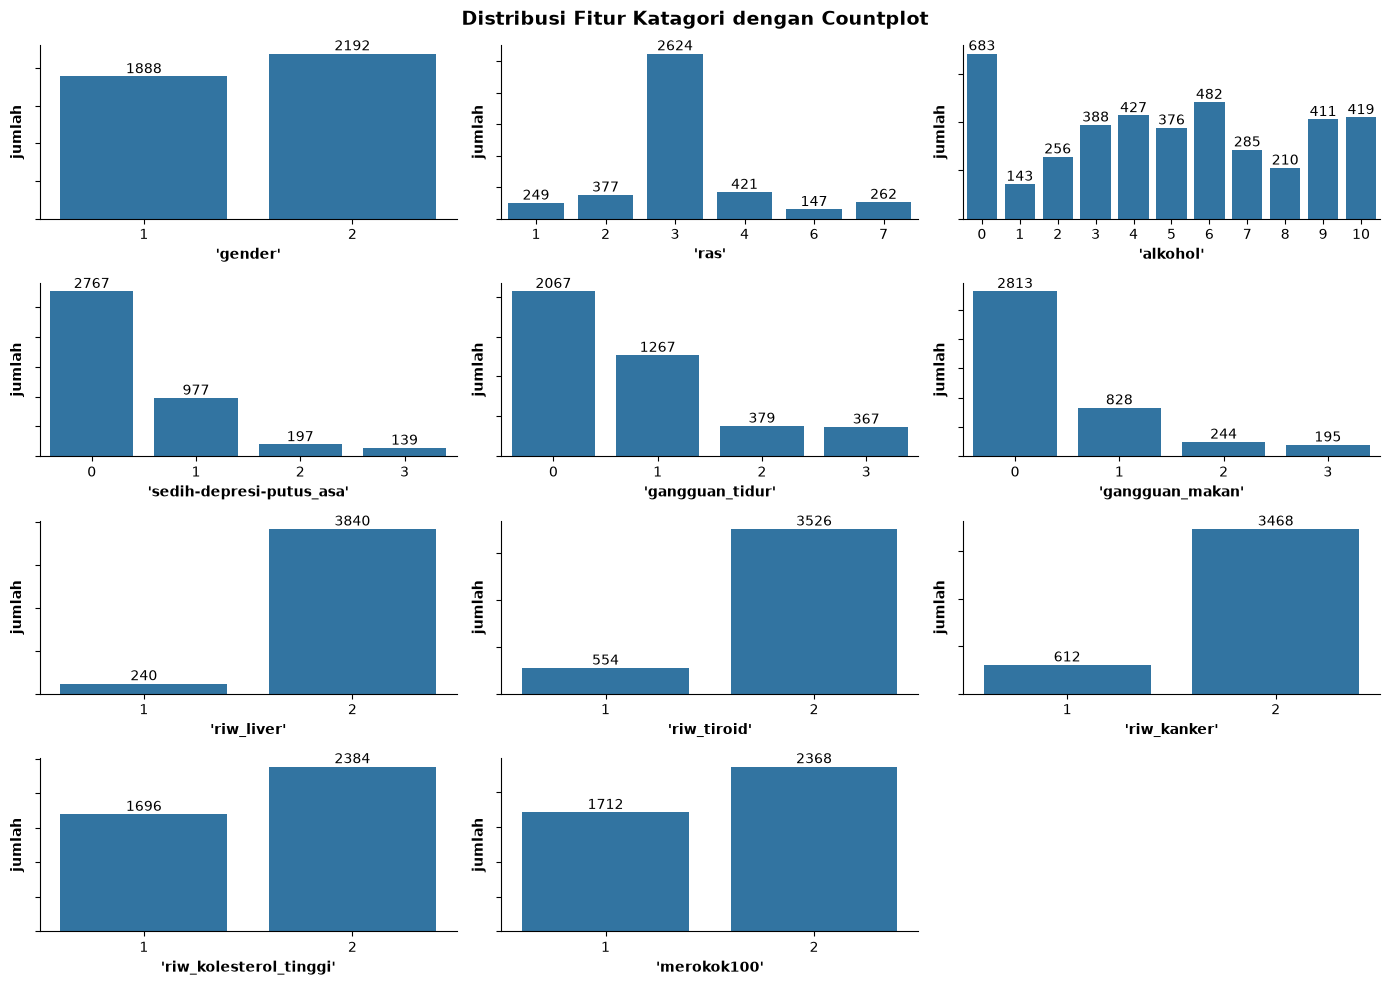

In [163]:
fig, ax = plt.subplots(4, 3, figsize=(14, 10))
ax = ax.flatten()
plt.suptitle("Distribusi Fitur Katagori dengan Countplot", fontsize=14, fontweight='bold')

for col, index in zip(cat_cols, range(len(cat_cols))):
    sns.countplot(ax=ax[cat_cols.index(col)], x=col, data=df)
    ax[cat_cols.index(col)].set_ylabel("jumlah", fontsize=10, fontweight='bold')
    ax[cat_cols.index(col)].set_xlabel(f"'{col}'", fontsize=10, fontweight='bold')
    ax[cat_cols.index(col)].bar_label(ax[cat_cols.index(col)].containers[0])
    ax[cat_cols.index(col)].spines['right'].set_visible(False)
    ax[cat_cols.index(col)].spines['top'].set_visible(False)
    ax[cat_cols.index(col)].set_yticklabels([])
# ax[len(num_cols)].set_axis_off()
ax[len(num_cols)+1].set_axis_off()
plt.tight_layout()
plt.show()

## 2. Drop Outlier

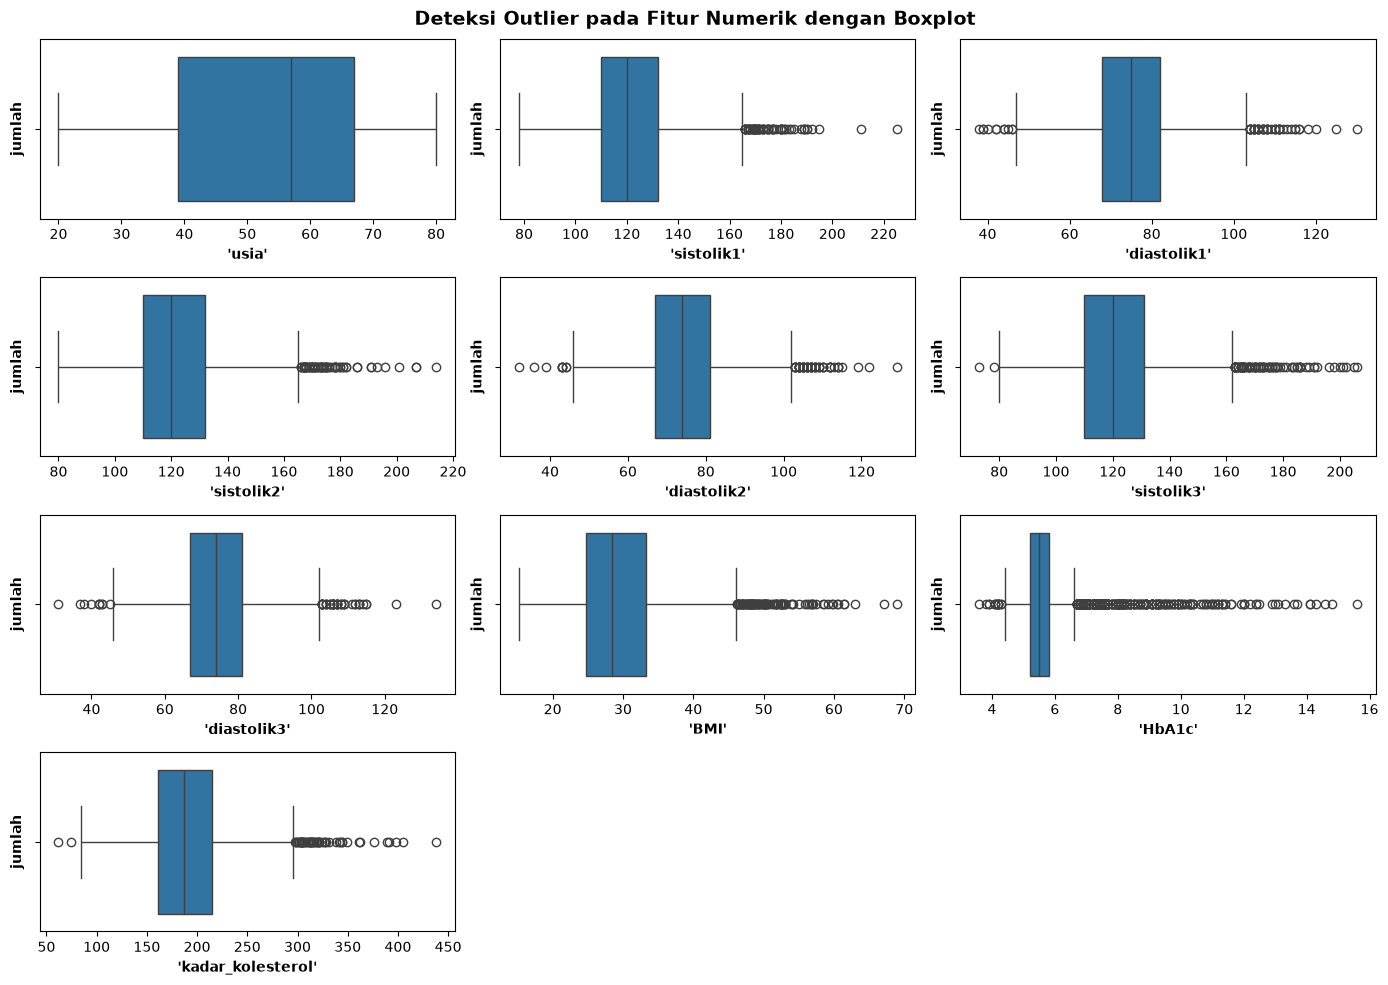

In [164]:
fig, ax = plt.subplots(4, 3, figsize=(14, 10))
ax = ax.flatten()
plt.suptitle("Deteksi Outlier pada Fitur Numerik dengan Boxplot", fontsize=14, fontweight='bold')

for col, index in zip(num_cols, range(len(num_cols))):
    sns.boxplot(ax=ax[num_cols.index(col)], x=col, data=df)
    ax[num_cols.index(col)].set_xlabel(f"'{col}'", fontsize=10, fontweight='bold')
    ax[num_cols.index(col)].set_ylabel("jumlah", fontsize=10, fontweight='bold')

ax[len(num_cols)].set_axis_off()
ax[len(num_cols)+1].set_axis_off()
plt.tight_layout()
plt.show()

## 3. Rekayasa Fitur

### 3.1 Memperbaiki Nilai pada Fitur Usia

- Terdapat kolom unik yaitu kolom `usia` yang memiliki tipe data campuran (numerik untuk umur 0 sampai 79, dan katagori untuk nilai 80 ke atas) sehingga perlu perlakuan khusus dengan mengubah kolom `usia` menjadi katagori.

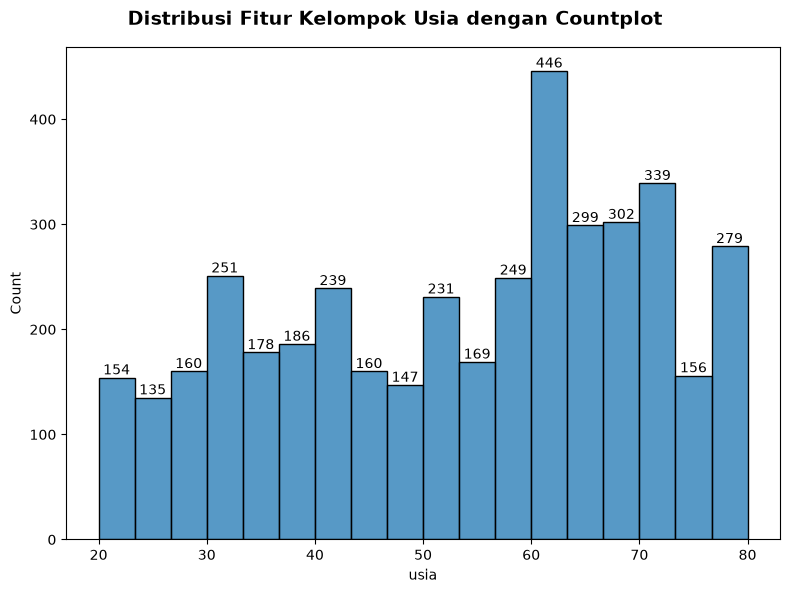

In [165]:
fig, ax = plt.subplots(figsize=(8, 6))
plt.suptitle("Distribusi Fitur Kelompok Usia dengan Countplot", fontsize=14, fontweight='bold')
sns.histplot(x='usia', data=df)
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

In [166]:
df['usia'] = df['usia'].replace(80, 85)

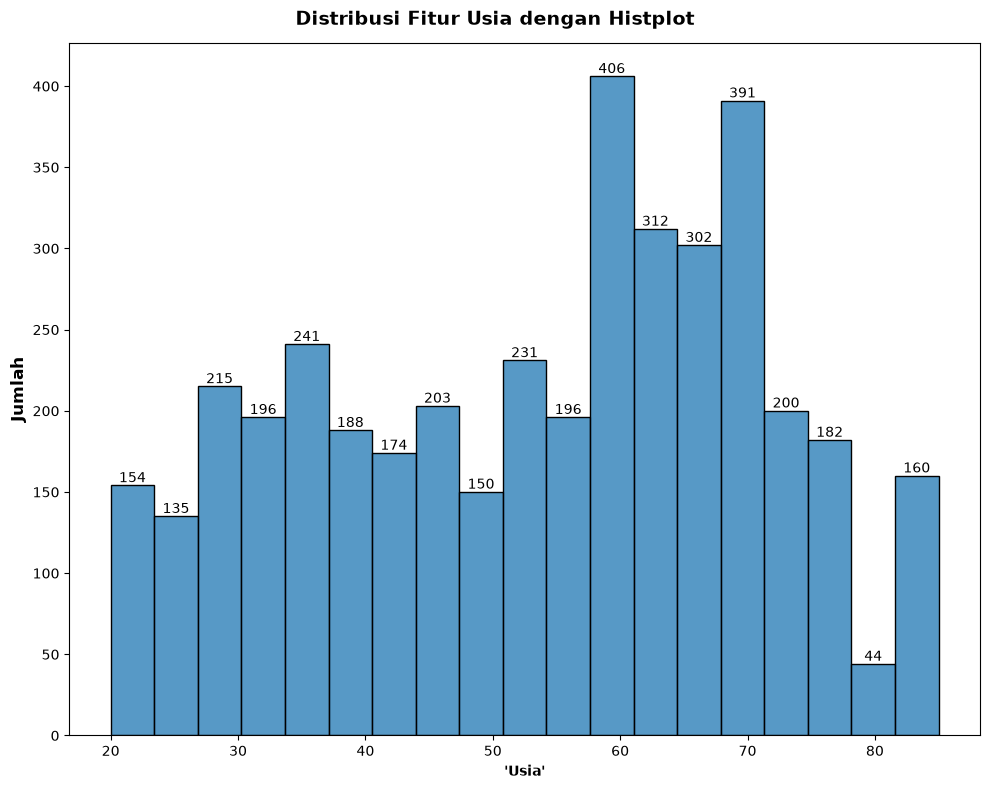

In [167]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.suptitle("Distribusi Fitur Usia dengan Histplot", fontsize=14, fontweight='bold')
sns.histplot(x='usia', data=df)
ax.set_xlabel("'Usia'", fontsize=10, fontweight='bold')
ax.set_ylabel("Jumlah", fontsize=12, fontweight='bold')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()

### 3.2 Membuat Fitur Tekanan Darah

**Mean Arterial Pressure**</br>
MAP dapat dihitung menggunakan rumus berikut:</br>
Diastolik + 1/3 (Sistolik - Diastolik)

In [168]:
rata2_sistolik = (df['sistolik1'] + df['sistolik2'] + df['sistolik3'])/3
rata2_diastolik = (df['diastolik1'] + df['diastolik2'] + df['diastolik3'])/3
df['tekanan_darah'] = rata2_diastolik + (rata2_sistolik - rata2_diastolik)/3
df['tekanan_darah'] = df['tekanan_darah'].round().astype('int64')

In [169]:
# drop kolom sistolik dan daistolik
df = df.drop(columns=['sistolik1', 'sistolik2', 'sistolik3', 'diastolik1', 'diastolik2', 'diastolik3'])

In [170]:
df.shape

(4080, 17)

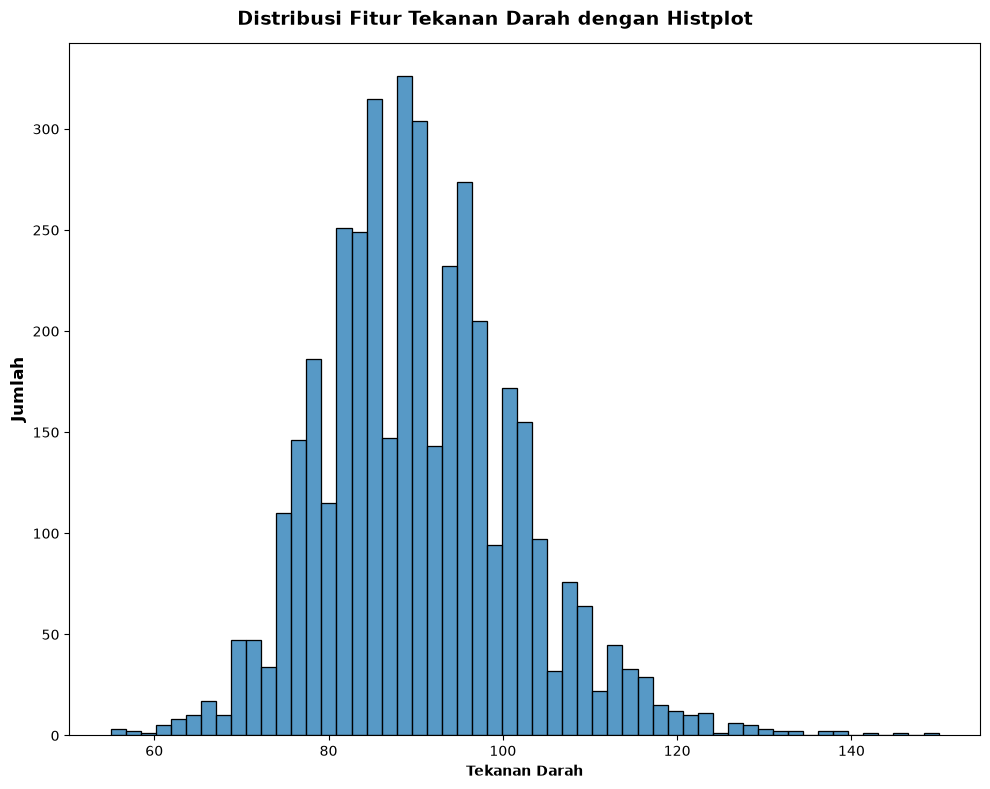

In [171]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.suptitle("Distribusi Fitur Tekanan Darah dengan Histplot", fontsize=14, fontweight='bold')
sns.histplot(x='tekanan_darah', data=df)
ax.set_xlabel('Tekanan Darah',fontweight='bold')
ax.set_ylabel("Jumlah", fontsize=12, fontweight='bold')
# ax.bar_label(ax.containers[0])
plt.tight_layout()
# plt.savefig('distribusi tekanan darah.png')
plt.show()

### 3.3 Memperbaiki Urutan Katagori Fitur Alkohol

In [172]:
alkohol_mapping = {
    0: 0, 10: 1, 9: 2, 8: 3, 7: 4,
    6: 5, 5: 6, 4: 7, 3: 8, 2: 9, 1: 10,
}
df['alkohol'] = df['alkohol'].map(alkohol_mapping)

## 4. Encoding

### 4.1 Biner

In [173]:
bin_cols = ['gender', 'riw_liver', 'riw_tiroid', 'riw_kanker', 'riw_kolesterol_tinggi', 'merokok100', 'diabetes']
for col in bin_cols:
    df[col] = df[col].cat.rename_categories({2:0})

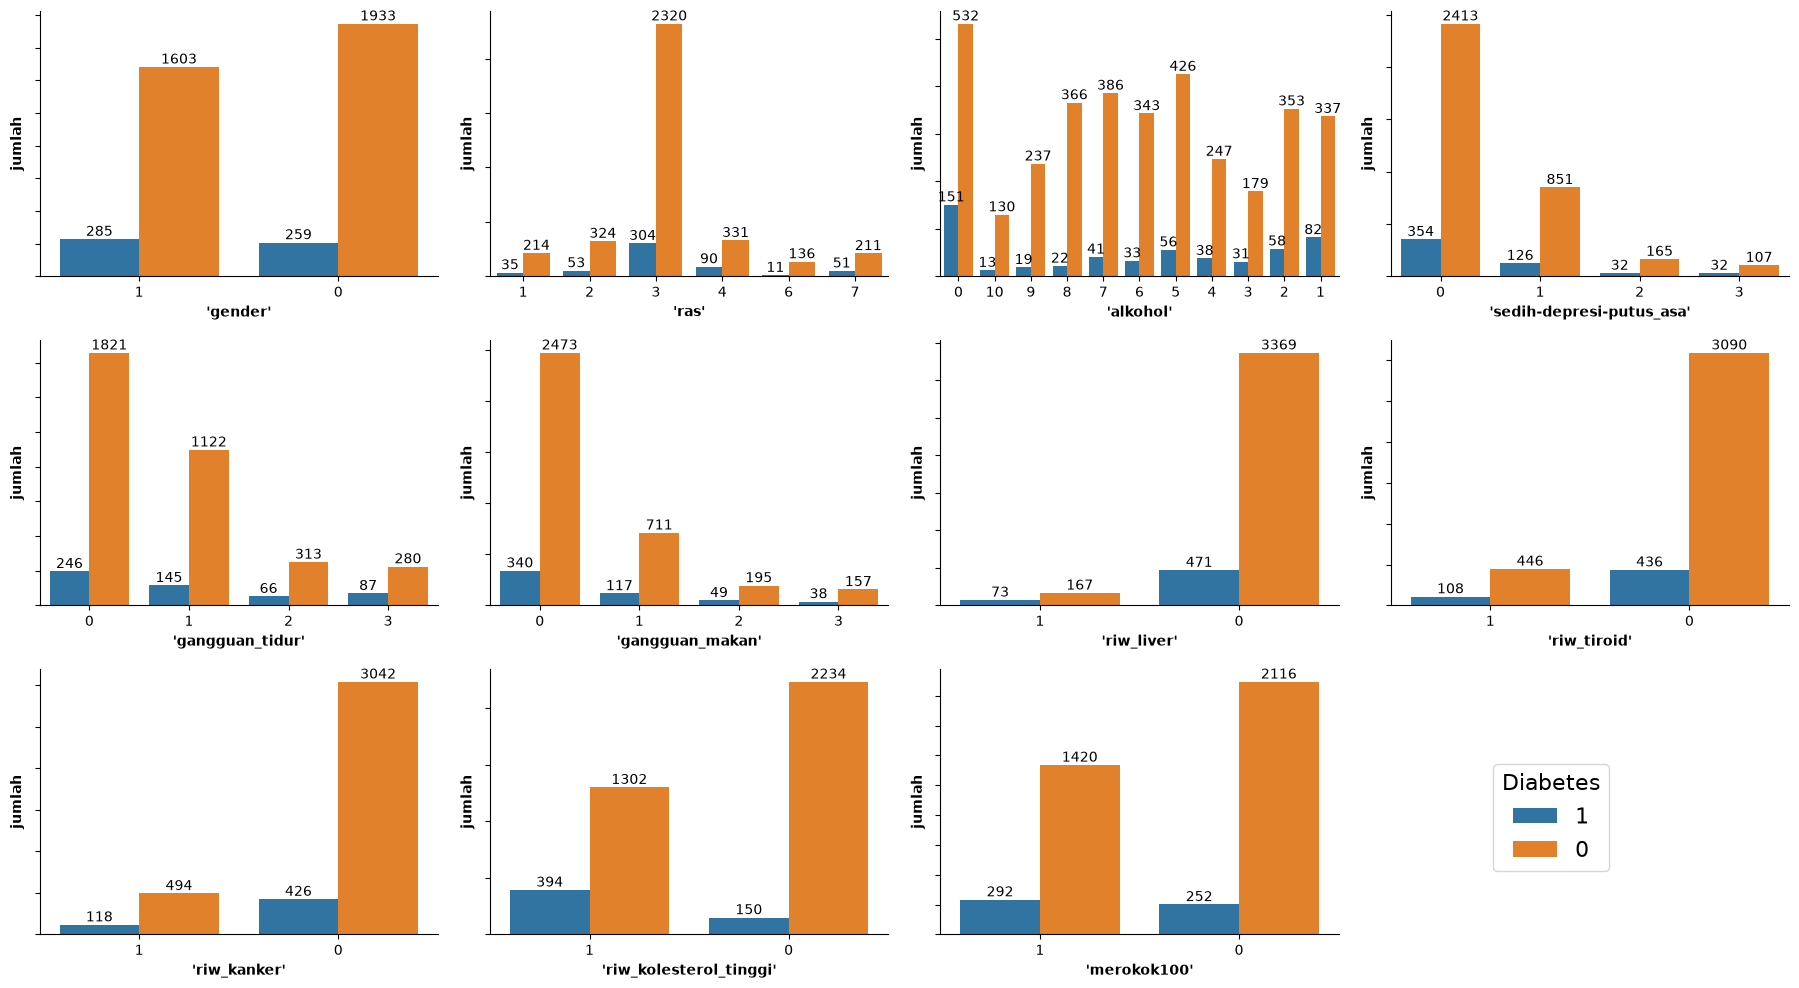

In [174]:
fig, ax = plt.subplots(3, 4, figsize=(13, 10))
ax = ax.flatten()
# plt.suptitle("Distribusi Fitur Katagori dengan Countplot", fontsize=14, fontweight='bold')

for col, index in zip(cat_cols, range(len(cat_cols))):
    sns.countplot(ax=ax[cat_cols.index(col)], x=col, data=df, hue='diabetes')
    ax[cat_cols.index(col)].set_ylabel("jumlah", fontsize=10, fontweight='bold')
    ax[cat_cols.index(col)].set_xlabel(f"'{col}'", fontsize=10, fontweight='bold')
    ax[cat_cols.index(col)].bar_label(ax[cat_cols.index(col)].containers[0])
    ax[cat_cols.index(col)].bar_label(ax[cat_cols.index(col)].containers[1])
    ax[cat_cols.index(col)].spines['right'].set_visible(False)
    ax[cat_cols.index(col)].spines['top'].set_visible(False)
    ax[cat_cols.index(col)].set_yticklabels([])
    ax[cat_cols.index(col)].legend_.remove()
# ax[len(num_cols)].set_axis_off()
handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right",bbox_to_anchor=(1.25, 0.24), frameon=True, fontsize=16,title="Diabetes",title_fontsize=16)
# plt.tight_layout(rect=[0, 0.03, 1.3, 1])
plt.tight_layout(rect=[0, 0, 1.4, 1])
ax[len(num_cols)+1].set_axis_off()
plt.savefig("distribusi_kategori_HUE_diabetes.png", dpi=400, bbox_inches='tight')
plt.show()

---

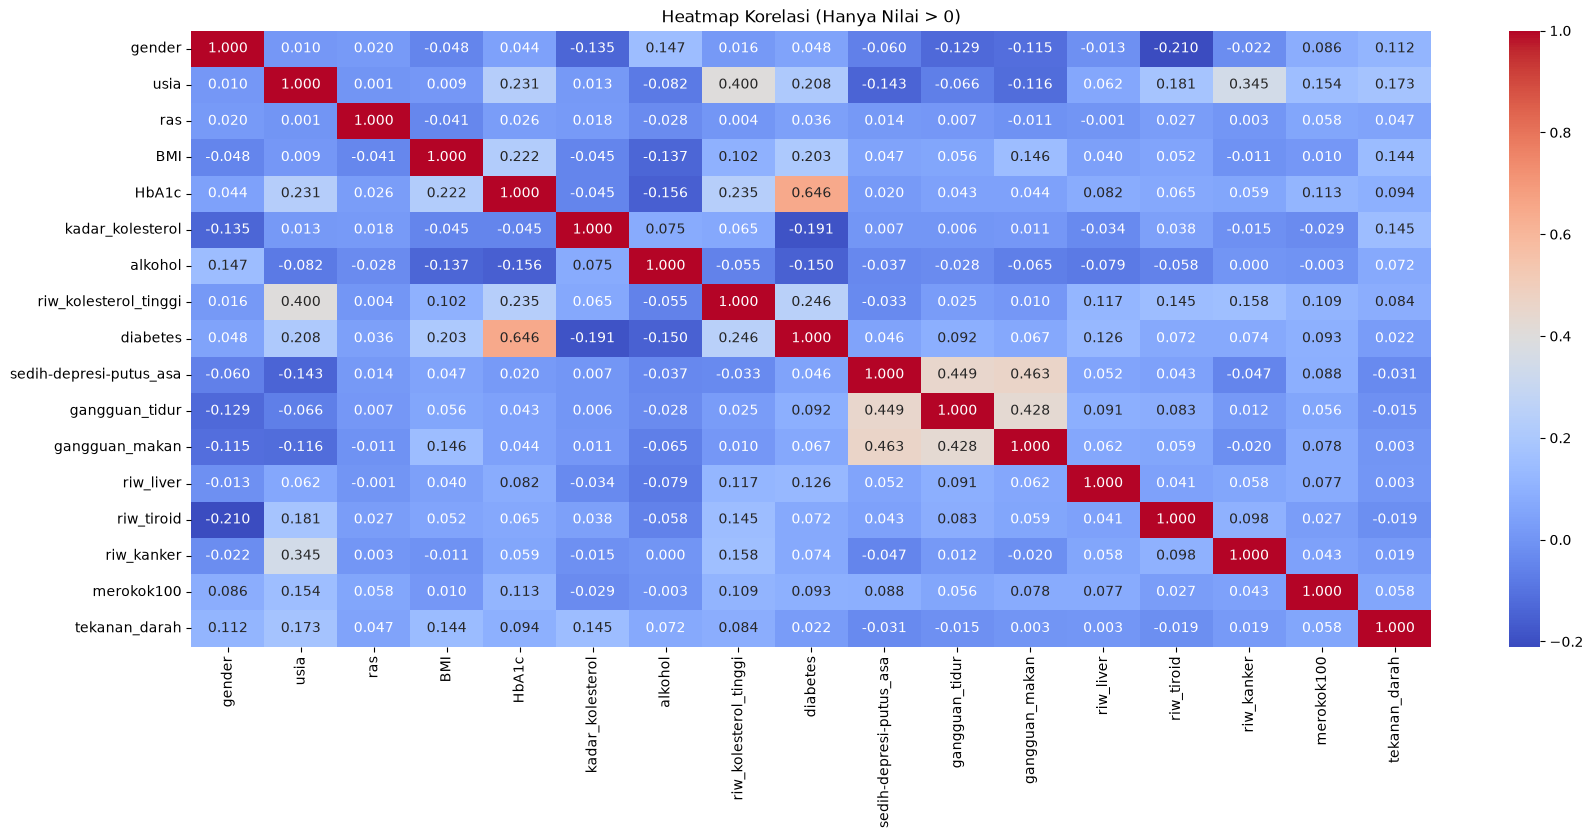

In [175]:
plt.figure(figsize=(20, 8))
# Hitung korelasi
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f", cbar=True)
plt.title('Heatmap Korelasi (Hanya Nilai > 0)')
plt.xticks(rotation=90)
plt.show()

### 4.2 Nominal

In [176]:
df = pd.get_dummies(df, columns=['ras'], prefix='ras', drop_first=True)

In [177]:
df['diabetes'].value_counts()

diabetes
0    3536
1     544
Name: count, dtype: int64

## 5. Splitting

In [178]:
X = df.drop(columns='diabetes')
y = df['diabetes']

In [179]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42, stratify=y)

In [180]:
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}, y_train: {y_train.shape}, y_test: {y_test.shape}")

X_train: (2856, 20), X_test: (1224, 20), y_train: (2856,), y_test: (1224,)


## 6. Normalization

In [181]:
# Normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# export scaler
with open('../pkl/scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [182]:
# Mengubah kembali numpy array menjadi dataframe
X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

## 7. Resampling

Resampling dengan SMOTE-ENN

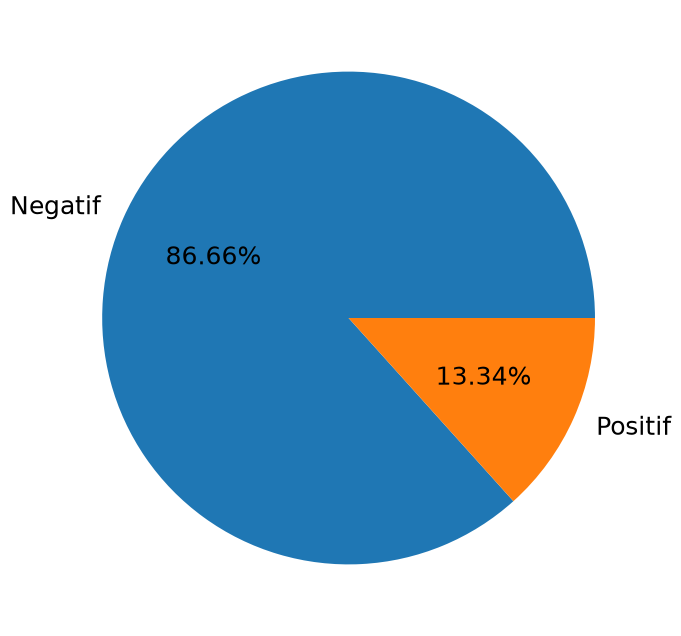

In [183]:
fig, ax = plt.subplots(figsize=(8, 8))
# plt.suptitle("Pie Chart", fontsize=14, fontweight='bold')
# sns.set(style="whitegrid")
plt.pie(x=y_train.value_counts(), labels=['Negatif', 'Positif'], autopct='%1.2f%%', textprops={'fontsize': 18, 'color': 'black'} )
# plt.tight_layout()
# plt.savefig('before_resampling.png')
plt.show()

In [184]:
from imblearn.combine import SMOTEENN
from collections import Counter

counter = Counter(y_train)
print('Sebelum SMOTE-ENN', counter)

SMOTEENN = SMOTEENN(random_state=42)
X_train, y_train = SMOTEENN.fit_resample(X_train, y_train)

counter = Counter(y_train)
print('Setelah SMOTE-ENN', counter)

Sebelum SMOTE-ENN Counter({0: 2475, 1: 381})
Setelah SMOTE-ENN Counter({1: 2334, 0: 1783})


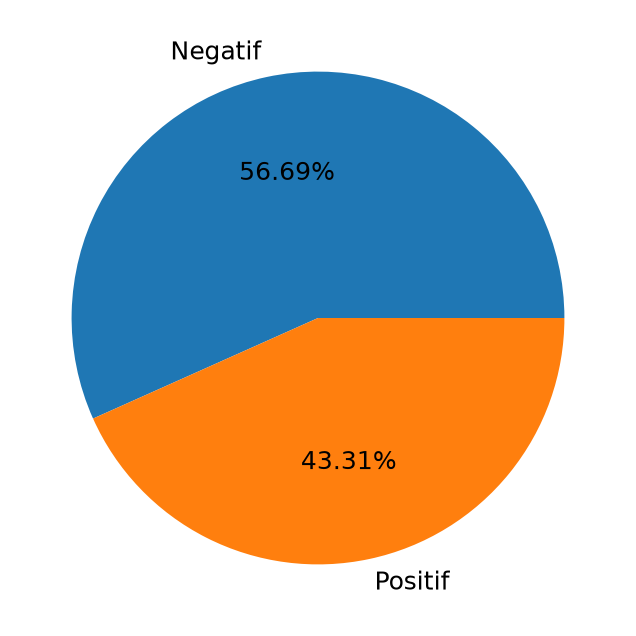

In [185]:
fig, ax = plt.subplots(figsize=(8, 8))
# plt.suptitle("Pie Chart", fontsize=14, fontweight='bold')
# sns.set(style="whitegrid")
plt.pie(x=y_train.value_counts(), labels=['Negatif', 'Positif'], autopct='%1.2f%%', textprops={'fontsize': 18, 'color': 'black'} )
# plt.tight_layout()
# plt.savefig('after_resampling.png')
plt.show()

# Modeling

## 1. KNN

In [186]:
model_knn = KNeighborsClassifier()
model_knn.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [187]:
model_knn_pred = model_knn.predict(X_test)

In [188]:
print("Akurasi KNN: ", accuracy_score(y_test, model_knn_pred))

Akurasi KNN:  0.7034313725490197


In [189]:
accuracy_knn = accuracy_score(y_test, model_knn_pred)
precision_knn = precision_score(y_test, model_knn_pred)
recall_knn = recall_score(y_test, model_knn_pred)
f1_knn = f1_score(y_test, model_knn_pred)
roc_auc_knn = roc_auc_score(y_test, model_knn_pred)

print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")

Accuracy: 0.7034
Recall: 0.6748
Precision: 0.2619
F1-Score: 0.3774


In [190]:
print("Classification Report KNN\n")
print(classification_report(y_test, model_knn_pred))

Classification Report KNN

              precision    recall  f1-score   support

           0       0.93      0.71      0.81      1061
           1       0.26      0.67      0.38       163

    accuracy                           0.70      1224
   macro avg       0.60      0.69      0.59      1224
weighted avg       0.84      0.70      0.75      1224



In [191]:
from sklearn.metrics import confusion_matrix
tn_knn, fp_knn, fn_knn, tp_knn = confusion_matrix(y_test, model_knn_pred).ravel()

# Hitung spesifisitas
specificity_knn = tn_knn / (tn_knn + fp_knn)
sensitiviy_knn = tp_knn / (tp_knn + fn_knn)

In [192]:
print(f"True Negative (TN): {tn_knn}")
print(f"False Positive (FP): {fp_knn}")
print(f"Spesifisitas: {specificity_knn:.4f}")

True Negative (TN): 751
False Positive (FP): 310
Spesifisitas: 0.7078


In [193]:
print(f"True Positive (TN): {tp_knn}")
print(f"False Negative (FP): {fn_knn}")
print(f"Sensitivitas: {sensitiviy_knn:.4f}")

True Positive (TN): 110
False Negative (FP): 53
Sensitivitas: 0.6748


In [194]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred_proba_knn = model_knn.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif
roc_auc_knn = roc_auc_score(y_test, y_pred_proba_knn)
pr_auc_knn = average_precision_score(y_test, y_pred_proba_knn)
print(f"ROC-AUC Score: {roc_auc_knn:.4f}")
print(f"PR-AUC Score: {pr_auc_knn:.4f}")

ROC-AUC Score: 0.7284
PR-AUC Score: 0.2591


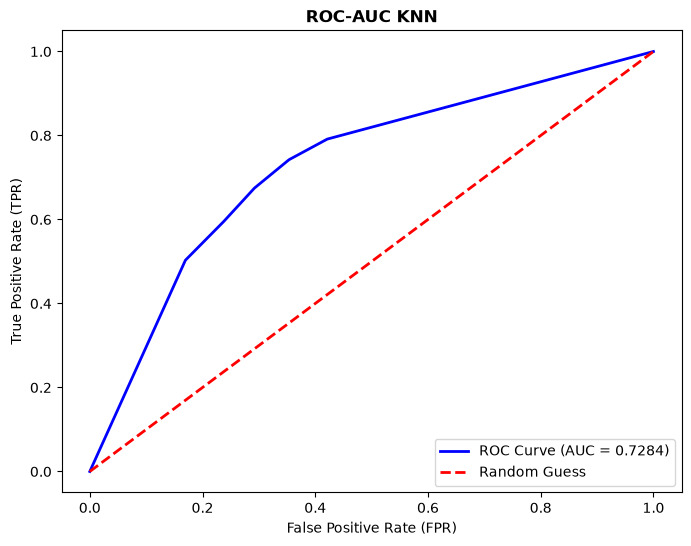

In [195]:
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_pred_proba_knn)

# Visualisasi kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_knn, tpr_knn, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_knn:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-AUC KNN', fontweight='bold')
plt.legend(loc='lower right')
plt.savefig('ROC-AUC_KNN_tanpa_HYP.png', dpi=400)
plt.show()

## 2. XGBoost

In [196]:
model_xgb = xgb.XGBClassifier(objective='binary:logistic',random_state=42)
model_xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [197]:
model_xgb_pred = model_xgb.predict(X_test)

In [198]:
print("Akurasi XGB: ", accuracy_score(y_test, model_xgb_pred))

Akurasi XGB:  0.9387254901960784


In [199]:
accuracy_xgb = accuracy_score(y_test, model_xgb_pred)
precision_xgb = precision_score(y_test, model_xgb_pred)
recall_xgb = recall_score(y_test, model_xgb_pred)
f1_xgb = f1_score(y_test, model_xgb_pred)
roc_auc_xgb = roc_auc_score(y_test, model_xgb_pred)

print(f"Accuracy: {accuracy_xgb:.4f}")
print(f"Recall: {recall_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")

Accuracy: 0.9387
Recall: 0.8528
Precision: 0.7316
F1-Score: 0.7875


In [200]:
print("Classification Report XGBoost\n")
print(classification_report(y_test, model_xgb_pred))

Classification Report XGBoost

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1061
           1       0.73      0.85      0.79       163

    accuracy                           0.94      1224
   macro avg       0.85      0.90      0.88      1224
weighted avg       0.94      0.94      0.94      1224



In [201]:
from sklearn.metrics import confusion_matrix
tn_xgb, fp_xgb, fn_xgb, tp_xgb = confusion_matrix(y_test, model_xgb_pred).ravel()

# Hitung spesifisitas
specificity_xgb = tn_xgb / (tn_xgb + fp_xgb)
sensitiviy_xgb = tp_xgb / (tp_xgb + fn_xgb)

In [202]:
print(f"True Negative (TN): {tn_xgb}")
print(f"False Positive (FP): {fp_xgb}")
print(f"Spesifisitas: {specificity_xgb:.4f}")

True Negative (TN): 1010
False Positive (FP): 51
Spesifisitas: 0.9519


In [203]:
print(f"True Positive (TN): {tp_xgb}")
print(f"False Negative (FP): {fn_xgb}")
print(f"Sensitivitas: {sensitiviy_xgb:.4f}")

True Positive (TN): 139
False Negative (FP): 24
Sensitivitas: 0.8528


In [204]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
pr_auc_xgb = average_precision_score(y_test, y_pred_proba_xgb)
print(f"ROC-AUC Score: {roc_auc_xgb:.4f}")
print(f"PR-AUC Score: {pr_auc_xgb:.4f}")

ROC-AUC Score: 0.9553
PR-AUC Score: 0.8606


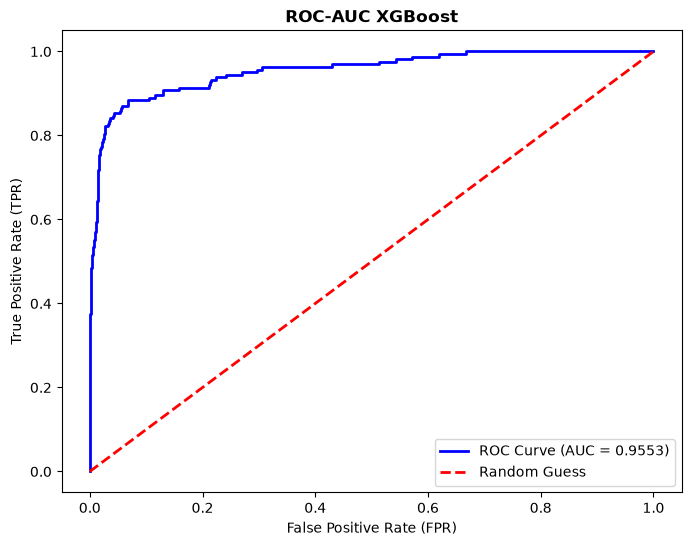

In [205]:
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_xgb)

# Visualisasi kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-AUC XGBoost', fontweight='bold')
plt.legend(loc='lower right')
plt.savefig('ROC-AUC_XGBoost_tanpa_HYP.png', dpi=400)
plt.show()

## 3. SVM

In [206]:
from sklearn.svm import SVC
model_svm = SVC(probability=True, random_state=42)
model_svm.fit(X_train, y_train)

d:\Portfolio\Project\Data Science\diabetes-prediction-based-on-risk-factors\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


In [207]:
model_svm_pred = model_svm.predict(X_test)

In [208]:
print("Akurasi SVM: ", accuracy_score(y_test, model_svm_pred))

Akurasi SVM:  0.8178104575163399


In [209]:
accuracy_svm = accuracy_score(y_test, model_svm_pred)
precision_svm = precision_score(y_test, model_svm_pred)
recall_svm = recall_score(y_test, model_svm_pred)
f1_svm = f1_score(y_test, model_svm_pred)
roc_auc_svm = roc_auc_score(y_test, model_svm_pred)

print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Recall: {recall_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"F1-Score: {f1_svm:.4f}")

Accuracy: 0.8178
Recall: 0.8344
Precision: 0.4096
F1-Score: 0.5495


In [210]:
print("Akurasi SVM: ", accuracy_score(y_test, model_svm_pred))

Akurasi SVM:  0.8178104575163399


In [211]:
print("Classification Report SVM\n")
print(classification_report(y_test, model_svm_pred))

Classification Report SVM

              precision    recall  f1-score   support

           0       0.97      0.82      0.89      1061
           1       0.41      0.83      0.55       163

    accuracy                           0.82      1224
   macro avg       0.69      0.82      0.72      1224
weighted avg       0.90      0.82      0.84      1224



In [212]:
from sklearn.metrics import confusion_matrix
tn_svm, fp_svm, fn_svm, tp_svm = confusion_matrix(y_test, model_svm_pred).ravel()

# Hitung spesifisitas
specificity_svm = tn_svm / (tn_svm + fp_svm)
sensitiviy_svm = tp_svm / (tp_svm + fn_svm)

In [213]:
print(f"True Negative (TN): {tn_svm}")
print(f"False Positive (FP): {fp_svm}")
print(f"Spesifisitas: {specificity_svm:.4f}")

True Negative (TN): 865
False Positive (FP): 196
Spesifisitas: 0.8153


In [214]:
print(f"True Positive (TN): {tp_svm}")
print(f"False Negative (FP): {fn_svm}")
print(f"Sensitivitas: {sensitiviy_svm:.4f}")

True Positive (TN): 136
False Negative (FP): 27
Sensitivitas: 0.8344


In [215]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred_proba_svm = model_svm.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif
roc_auc_svm = roc_auc_score(y_test, y_pred_proba_svm)
pr_auc_svm = average_precision_score(y_test, y_pred_proba_svm)
print(f"ROC-AUC Score: {roc_auc_svm:.4f}")
print(f"PR-AUC Score: {pr_auc_svm:.4f}")

ROC-AUC Score: 0.9110
PR-AUC Score: 0.7134


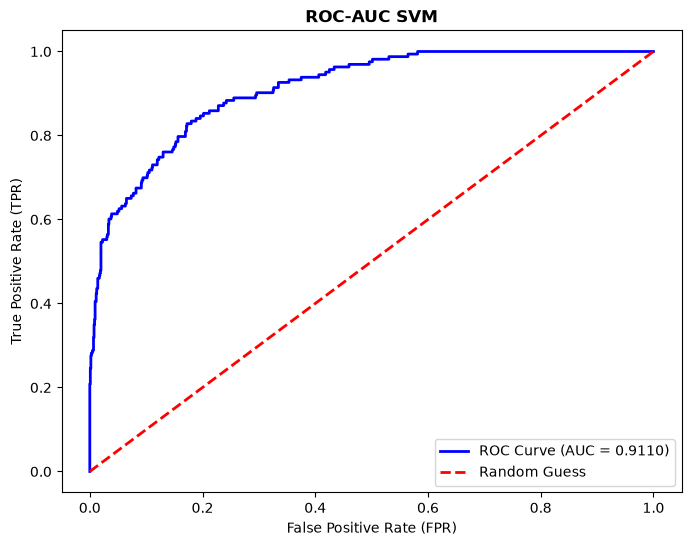

In [216]:
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_pred_proba_svm)

# Visualisasi kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_svm, tpr_svm, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_svm:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-AUC SVM', fontweight='bold')
plt.legend(loc='lower right')
plt.savefig('ROC-AUC_SVM_tanpa_HYP.png', dpi=400)
plt.show()

## 4. Random Forest

In [217]:
from sklearn.ensemble import RandomForestClassifier

In [218]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [219]:
model_rf_pred = model_rf.predict(X_test)

In [220]:
print("Akurasi RF: ", accuracy_score(y_test, model_rf_pred))

Akurasi RF:  0.928921568627451


In [221]:
accuracy_rf = accuracy_score(y_test, model_rf_pred)
precision_rf = precision_score(y_test, model_rf_pred)
recall_rf = recall_score(y_test, model_rf_pred)
f1_rf = f1_score(y_test, model_rf_pred)
roc_auc_rf = roc_auc_score(y_test, model_rf_pred)

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"F1-Score: {f1_rf:.4f}")

Accuracy: 0.9289
Recall: 0.8712
Precision: 0.6827
F1-Score: 0.7655


In [222]:
print("Classification Report RF\n")
print(classification_report(y_test, model_rf_pred))

Classification Report RF

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1061
           1       0.68      0.87      0.77       163

    accuracy                           0.93      1224
   macro avg       0.83      0.90      0.86      1224
weighted avg       0.94      0.93      0.93      1224



In [223]:
from sklearn.metrics import confusion_matrix
tn_rf, fp_rf, fn_rf, tp_rf = confusion_matrix(y_test, model_rf_pred).ravel()

# Hitung spesifisitas
specificity_rf = tn_rf / (tn_rf + fp_rf)
sensitiviy_rf = tp_rf / (tp_rf + fn_rf)

In [224]:
print(f"True Negative (TN): {tn_rf}")
print(f"False Positive (FP): {fp_rf}")
print(f"Spesifisitas: {specificity_rf:.4f}")

True Negative (TN): 995
False Positive (FP): 66
Spesifisitas: 0.9378


In [225]:
print(f"True Positive (TN): {tp_rf}")
print(f"False Negative (FP): {fn_rf}")
print(f"Sensitivitas: {sensitiviy_rf:.4f}")

True Positive (TN): 142
False Negative (FP): 21
Sensitivitas: 0.8712


In [226]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"ROC-AUC Score: {roc_auc_rf:4f}")

ROC-AUC Score: 0.960311


In [227]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred_proba_rf = model_rf.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
pr_auc_rf = average_precision_score(y_test, y_pred_proba_rf)
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")
print(f"PR-AUC Score: {pr_auc_rf:.4f}")

ROC-AUC Score: 0.9603
PR-AUC Score: 0.8521


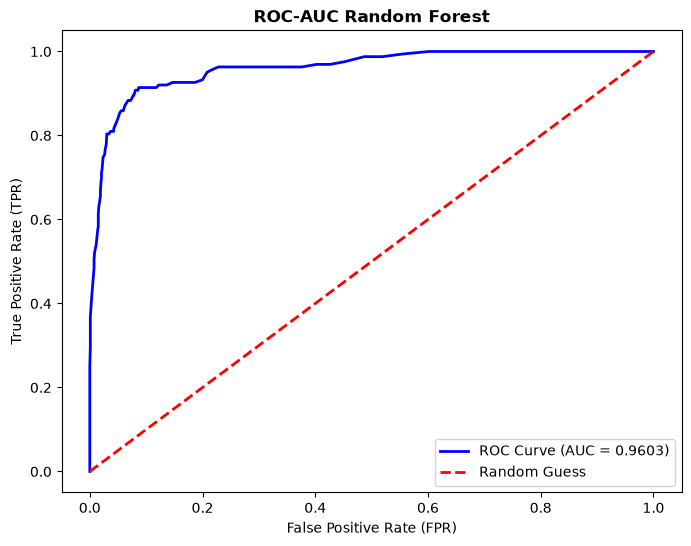

In [228]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)

# Visualisasi kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_rf:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-AUC Random Forest', fontweight='bold')
plt.legend(loc='lower right')
plt.savefig('ROC-AUC_RF_tanpa_HYP.png', dpi=400)
plt.show()

## 5. Hyperparameter

In [229]:
from sklearn.model_selection import StratifiedKFold
# Inisialisasi StratifiedKFold untuk cross-validation
stratified_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
from sklearn.model_selection import RandomizedSearchCV

### 5.1 KNN

In [230]:
hyp_knn_params = {
    'n_neighbors': [n for n in range(3, 20, 2)],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'p': [1, 2]  # untuk 'minkowski'
}

In [231]:
hyp_knn = KNeighborsClassifier()
clf_knn = GridSearchCV(
    estimator=hyp_knn,
    param_grid=hyp_knn_params,
    scoring='f1_weighted',
    cv=stratified_cv,
    verbose=1,
    n_jobs=-2
)

In [232]:
clf_knn.fit(X_train, y_train)

Fitting 10 folds for each of 108 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'manhattan', ...], 'n_neighbors': [3, 5, ...], 'p': [1, 2], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See

In [233]:
best_comb_knn = clf_knn.best_params_
best_comb_knn

{'metric': 'manhattan', 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}

In [234]:
clf_knn_pred = clf_knn.predict(X_test)
print("Akurasi HYPER KNN: ", accuracy_score(y_test, clf_knn_pred))

Akurasi HYPER KNN:  0.7589869281045751


In [235]:
accuracy_clf_knn = accuracy_score(y_test, clf_knn_pred)
precision_clf_knn = precision_score(y_test, clf_knn_pred)
recall_clf_knn = recall_score(y_test, clf_knn_pred)
f1_clf_knn = f1_score(y_test, clf_knn_pred)
roc_auc_clf_knn = roc_auc_score(y_test, clf_knn_pred)

print(f"Accuracy: {accuracy_clf_knn:.4f}")
print(f"Recall: {recall_clf_knn:.4f}")
print(f"Precision: {precision_clf_knn:.4f}")
print(f"F1-Score: {f1_clf_knn:.4f}")

Accuracy: 0.7590
Recall: 0.6380
Precision: 0.3059
F1-Score: 0.4135


In [236]:
clf_knn_pred = clf_knn.predict(X_test)
print("Akurasi HYPER KNN: ", accuracy_score(y_test, clf_knn_pred))

Akurasi HYPER KNN:  0.7589869281045751


In [237]:
print(classification_report(y_test, clf_knn_pred))

              precision    recall  f1-score   support

           0       0.93      0.78      0.85      1061
           1       0.31      0.64      0.41       163

    accuracy                           0.76      1224
   macro avg       0.62      0.71      0.63      1224
weighted avg       0.85      0.76      0.79      1224



In [238]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred_proba_clf_knn = clf_knn.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif
roc_auc_clf_knn = roc_auc_score(y_test, y_pred_proba_clf_knn)
pr_auc_clf_knn = average_precision_score(y_test, y_pred_proba_clf_knn)
print(f"ROC-AUC Score: {roc_auc_clf_knn:.4f}")
print(f"PR-AUC Score: {pr_auc_clf_knn:.4f}")

ROC-AUC Score: 0.7299
PR-AUC Score: 0.2753


In [239]:
from sklearn.metrics import confusion_matrix
tn_clf_knn, fp_clf_knn, fn_clf_knn, tp_clf_knn = confusion_matrix(y_test, clf_knn_pred).ravel()

# Hitung spesifisitas
specificity_clf_knn = tn_clf_knn / (tn_clf_knn + fp_clf_knn)
sensitiviy_clf_knn = tp_clf_knn / (tp_clf_knn + fn_clf_knn)

In [240]:
print(f"True Negative (TN): {tn_clf_knn}")
print(f"False Positive (FP): {fp_clf_knn}")
print(f"Spesifisitas: {specificity_clf_knn:.4f}")

True Negative (TN): 825
False Positive (FP): 236
Spesifisitas: 0.7776


In [241]:
print(f"True Positive (TN): {tp_clf_knn}")
print(f"False Negative (FP): {fn_clf_knn}")
print(f"Sensitivitas: {sensitiviy_clf_knn:.4f}")

True Positive (TN): 104
False Negative (FP): 59
Sensitivitas: 0.6380


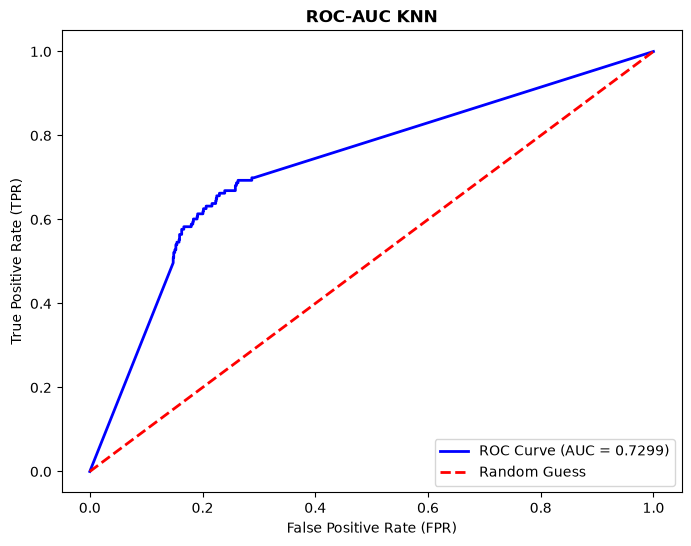

In [242]:
fpr_clf_knn, tpr_clf_knn, thresholds_knn = roc_curve(y_test, y_pred_proba_clf_knn)

# Visualisasi kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_clf_knn, tpr_clf_knn, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_clf_knn:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-AUC KNN', fontweight='bold')
plt.legend(loc='lower right')
plt.savefig('ROC-AUC_KNN_dengan_HYP.png', dpi=400)
plt.show()

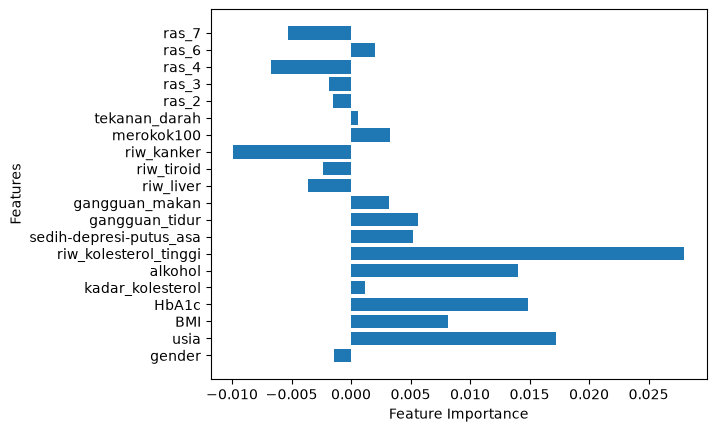

In [243]:
from sklearn.inspection import permutation_importance
result_knn = permutation_importance(clf_knn, X_test, y_test, n_repeats=10, random_state=42)
importance_knn = result_knn.importances_mean
#visualisasi
import matplotlib.pyplot as plt
plt.barh(X_train.columns, importance_knn)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

### 5.2 XGBoost

In [244]:
hyp_xgb_params = {
    'n_estimators': [400, 500],
    'learning_rate': [.2, .1, .05],
    'max_depth': [7, 8, 9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8]
}

In [245]:
hyp_xgb = xgb.XGBClassifier(objective='binary:logistic', 
                            random_state=42)
clf_xgb = GridSearchCV(
    estimator=hyp_xgb,
    param_grid=hyp_xgb_params,
    scoring='f1_weighted',
    cv=stratified_cv,
    verbose=1,
    n_jobs=-2
)

In [246]:
clf_xgb.fit(X_train, y_train)

Fitting 10 folds for each of 648 candidates, totalling 6480 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.7, 0.8], 'gamma': [0, 0.1, ...], 'learning_rate': [0.2, 0.1, ...], 'max_depth': [7, 8, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metriceva

In [247]:
clf_xgb.best_params_

{'colsample_bytree': 0.8,
 'gamma': 0,
 'learning_rate': 0.05,
 'max_depth': 7,
 'min_child_weight': 1,
 'n_estimators': 500,
 'subsample': 0.7}

In [248]:
clf_xgb_pred = clf_xgb.predict(X_test)
print("Akurasi HYPER XGB: ", accuracy_score(y_test, clf_xgb_pred))

Akurasi HYPER XGB:  0.9370915032679739


In [249]:
accuracy_clf_xgb = accuracy_score(y_test, clf_xgb_pred)
precision_clf_xgb = precision_score(y_test, clf_xgb_pred)
recall_clf_xgb = recall_score(y_test, clf_xgb_pred)
f1_clf_xgb = f1_score(y_test, clf_xgb_pred)
roc_auc_clf_xgb = roc_auc_score(y_test, clf_xgb_pred)

print(f"Accuracy: {accuracy_clf_xgb:.4f}")
print(f"Recall: {recall_clf_xgb:.4f}")
print(f"Precision: {precision_clf_xgb:.4f}")
print(f"F1-Score: {f1_clf_xgb:.4f}")

Accuracy: 0.9371
Recall: 0.8650
Precision: 0.7194
F1-Score: 0.7855


In [250]:
print(classification_report(y_test, clf_xgb_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96      1061
           1       0.72      0.87      0.79       163

    accuracy                           0.94      1224
   macro avg       0.85      0.91      0.87      1224
weighted avg       0.94      0.94      0.94      1224



In [251]:
clf_xgb.best_score_

np.float64(0.9761830556232379)

In [252]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred_proba_clf_xgb = clf_xgb.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif
roc_auc_clf_xgb = roc_auc_score(y_test, y_pred_proba_clf_xgb)
pr_auc_clf_xgb = average_precision_score(y_test, y_pred_proba_clf_xgb)
print(f"ROC-AUC Score: {roc_auc_clf_xgb:.4f}")
print(f"PR-AUC Score: {pr_auc_clf_xgb:.4f}")

ROC-AUC Score: 0.9580
PR-AUC Score: 0.8616


In [253]:
from sklearn.metrics import confusion_matrix
tn_clf_xgb, fp_clf_xgb, fn_clf_xgb, tp_clf_xgb = confusion_matrix(y_test, clf_xgb_pred).ravel()

# Hitung spesifisitas
specificity_clf_xgb = tn_clf_xgb / (tn_clf_xgb + fp_clf_xgb)
sensitiviy_clf_xgb = tp_clf_xgb / (tp_clf_xgb + fn_clf_xgb)

In [254]:
print(f"True Negative (TN): {tn_clf_xgb}")
print(f"False Positive (FP): {fp_clf_xgb}")
print(f"Spesifisitas: {specificity_clf_xgb:.4f}")

True Negative (TN): 1006
False Positive (FP): 55
Spesifisitas: 0.9482


In [255]:
print(f"True Positive (TN): {tp_clf_xgb}")
print(f"False Negative (FP): {fn_clf_xgb}")
print(f"Sensitivitas: {sensitiviy_clf_xgb:.4f}")

True Positive (TN): 141
False Negative (FP): 22
Sensitivitas: 0.8650


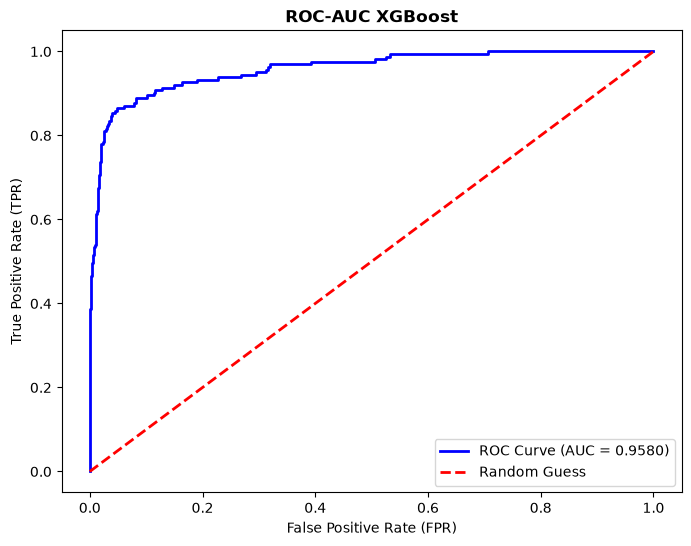

In [256]:
fpr_clf_xgb, tpr_clf_xgb, thresholds_xgb = roc_curve(y_test, y_pred_proba_clf_xgb)

# Visualisasi kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_clf_xgb, tpr_clf_xgb, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_clf_xgb:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-AUC XGBoost', fontweight='bold')
plt.legend(loc='lower right')
plt.savefig('ROC-AUC_XGBoost_dengan_HYP.png', dpi=400)
plt.show()

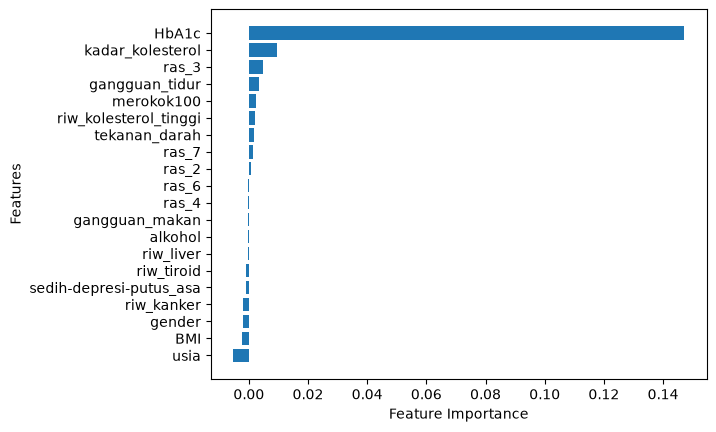

In [257]:
from sklearn.inspection import permutation_importance
result_xgb = permutation_importance(clf_xgb, X_test, y_test, n_repeats=10, random_state=42)
importance_xgb = result_xgb.importances_mean

sorted_idx_xgb = importance_xgb.argsort()[::1]
#visualisasi
import matplotlib.pyplot as plt
plt.barh(X_train.columns[sorted_idx_xgb], importance_xgb[sorted_idx_xgb])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

### 5.3 SVM

In [258]:
hyp_svm_params = [
    # Linear kernel: hanya C
    {
        'kernel': ['linear'],
        'C': [0.01, 0.1, 1]
    },
    # RBF kernel: C dan gamma
    {
        'kernel': ['rbf'],
        'C': [0.01, 0.1, 1],
        'gamma': ['scale', 0.01, 0.1]
    },
    # Polynomial kernel: C, gamma, dan coef0
    {
        'kernel': ['poly'],
        'C': [0.01, 0.1, 1],
        'gamma': ['scale', 0.01, 0.1],
        'coef0': [float(c) for c in np.arange(0, 1, 0.1)],
        'degree': [2, 3]
    }
]


# hyp_svm_params = [svm_linear_params, svm_rbf_params, svm_poly_params]

In [259]:
hyp_svm = SVC(probability=True, random_state=42)
clf_svm = GridSearchCV(
    estimator=hyp_svm,
    param_grid=hyp_svm_params,
    scoring='f1_weighted',
    cv=stratified_cv,
    verbose=1,
    n_jobs=-2
)

In [260]:
clf_svm.fit(X_train, y_train)

Fitting 10 folds for each of 192 candidates, totalling 1920 fits


d:\Portfolio\Project\Data Science\diabetes-prediction-based-on-risk-factors\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC(probabili...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'C': [0.01, 0.1, ...], 'kernel': ['linear']}, {'C': [0.01, 0.1, ...], 'gamma': ['scale', 0.01, ...], 'kernel': ['rbf']}, ...]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metri

In [261]:
best_comb_svm = clf_svm.best_params_
best_comb_svm

{'C': 1, 'coef0': 0.9, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}

In [262]:
clf_svm_pred = clf_svm.predict(X_test)
print("Akurasi HYPER SVM: ", accuracy_score(y_test, clf_svm_pred))

Akurasi HYPER SVM:  0.8774509803921569


In [263]:
accuracy_clf_svm = accuracy_score(y_test, clf_svm_pred)
precision_clf_svm = precision_score(y_test, clf_svm_pred)
recall_clf_svm = recall_score(y_test, clf_svm_pred)
f1_clf_svm = f1_score(y_test, clf_svm_pred)
roc_auc_clf_svm = roc_auc_score(y_test, clf_svm_pred)

print(f"Accuracy: {accuracy_clf_svm:.4f}")
print(f"Recall: {recall_clf_svm:.4f}")
print(f"Precision: {precision_clf_svm:.4f}")
print(f"F1-Score: {f1_clf_svm:.4f}")

Accuracy: 0.8775
Recall: 0.8712
Precision: 0.5240
F1-Score: 0.6544


In [264]:
print(classification_report(y_test, clf_svm_pred))

              precision    recall  f1-score   support

           0       0.98      0.88      0.93      1061
           1       0.52      0.87      0.65       163

    accuracy                           0.88      1224
   macro avg       0.75      0.87      0.79      1224
weighted avg       0.92      0.88      0.89      1224



In [265]:
clf_svm.best_score_

np.float64(0.9661392431545099)

In [266]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred_proba_clf_svm = clf_svm.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif
roc_auc_clf_svm = roc_auc_score(y_test, y_pred_proba_clf_svm)
pr_auc_clf_svm = average_precision_score(y_test, y_pred_proba_clf_svm)
print(f"ROC-AUC Score: {roc_auc_clf_svm:.4f}")
print(f"PR-AUC Score: {pr_auc_clf_svm:.4f}")

ROC-AUC Score: 0.9354
PR-AUC Score: 0.8007


In [267]:
from sklearn.metrics import confusion_matrix
tn_clf_svm, fp_clf_svm, fn_clf_svm, tp_clf_svm = confusion_matrix(y_test, clf_svm_pred).ravel()

# Hitung spesifisitas
specificity_clf_svm = tn_clf_svm / (tn_clf_svm + fp_clf_svm)
sensitiviy_clf_svm = tp_clf_svm / (tp_clf_svm + fn_clf_svm)

In [268]:
print(f"True Negative (TN): {tn_clf_svm}")
print(f"False Positive (FP): {fp_clf_svm}")
print(f"Spesifisitas: {specificity_clf_svm:.4f}")

True Negative (TN): 932
False Positive (FP): 129
Spesifisitas: 0.8784


In [269]:
print(f"True Positive (TN): {tp_clf_svm}")
print(f"False Negative (FP): {fn_clf_svm}")
print(f"Sensitivitas: {sensitiviy_clf_svm:.4f}")

True Positive (TN): 142
False Negative (FP): 21
Sensitivitas: 0.8712


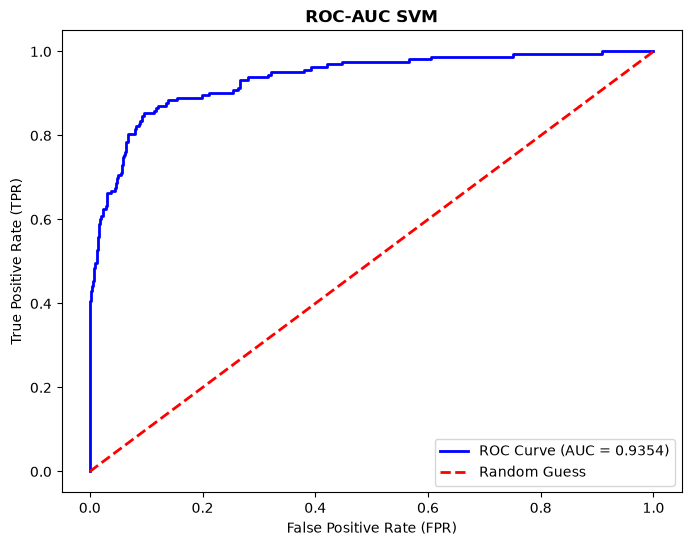

In [270]:
fpr_clf_svm, tpr_clf_svm, thresholds_svm = roc_curve(y_test, y_pred_proba_clf_svm)

# Visualisasi kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_clf_svm, tpr_clf_svm, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_clf_svm:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-AUC SVM', fontweight='bold')
plt.legend(loc='lower right')
plt.savefig('ROC-AUC_SVM_dengan_HYP.png', dpi=400)
plt.show()

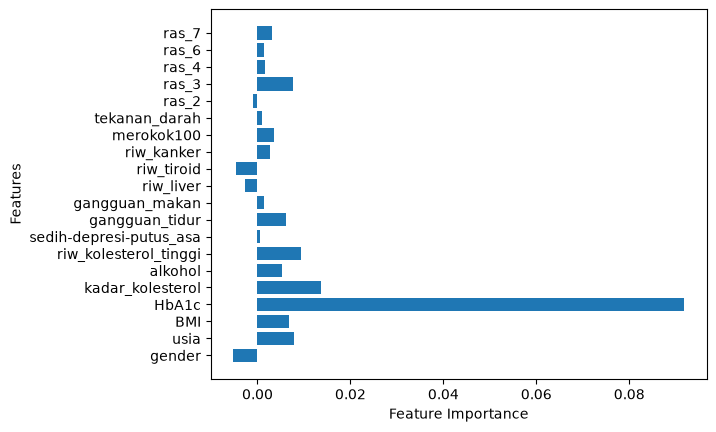

In [271]:
from sklearn.inspection import permutation_importance
result_svm = permutation_importance(clf_svm, X_test, y_test, n_repeats=10, random_state=42)
importance_svm= result_svm.importances_mean
#visualisasi
import matplotlib.pyplot as plt
plt.barh(X_train.columns, importance_svm)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

### 5.4 Random Forest

In [272]:
hyp_rf_params = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', 0.5],
}

In [273]:
hyp_rf = RandomForestClassifier(random_state=42)
clf_rf = GridSearchCV(
    estimator=hyp_rf,
    param_grid=hyp_rf_params,
    scoring='f1_weighted',
    cv=stratified_cv,
    verbose=1,
    n_jobs=-2
)

In [274]:
clf_rf.fit(X_train, y_train)

Fitting 10 folds for each of 432 candidates, totalling 4320 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-2
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about m

In [275]:
best_comb_rf = clf_rf.best_params_
best_comb_rf

{'max_depth': None,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 300}

In [276]:
clf_rf_pred = clf_rf.predict(X_test)
print("Akurasi HYPER Random Forest: ", accuracy_score(y_test, clf_rf_pred))

Akurasi HYPER Random Forest:  0.9321895424836601


In [277]:
accuracy_clf_rf = accuracy_score(y_test, clf_rf_pred)
precision_clf_rf = precision_score(y_test, clf_rf_pred)
recall_clf_rf = recall_score(y_test, clf_rf_pred)
f1_clf_rf = f1_score(y_test, clf_rf_pred)
roc_auc_clf_rf = roc_auc_score(y_test, clf_rf_pred)

print(f"Accuracy: {accuracy_clf_rf:.4f}")
print(f"Recall: {recall_clf_rf:.4f}")
print(f"Precision: {precision_clf_rf:.4f}")
print(f"F1-Score: {f1_clf_rf:.4f}")

Accuracy: 0.9322
Recall: 0.8773
Precision: 0.6942
F1-Score: 0.7751


In [278]:
print(classification_report(y_test, clf_rf_pred))

              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1061
           1       0.69      0.88      0.78       163

    accuracy                           0.93      1224
   macro avg       0.84      0.91      0.87      1224
weighted avg       0.94      0.93      0.94      1224



In [279]:
clf_rf.best_score_

np.float64(0.9759194072818437)

In [280]:
from sklearn.metrics import roc_auc_score, roc_curve
y_pred_proba_clf_rf = clf_rf.predict_proba(X_test)[:, 1]  # Probabilitas kelas positif
roc_auc_clf_rf = roc_auc_score(y_test, y_pred_proba_clf_rf)
pr_auc_clf_rf = average_precision_score(y_test, y_pred_proba_clf_rf)
print(f"ROC-AUC Score: {roc_auc_clf_rf:.4f}")
print(f"PR-AUC Score: {pr_auc_clf_rf:.4f}")

ROC-AUC Score: 0.9599
PR-AUC Score: 0.8570


In [281]:
from sklearn.metrics import confusion_matrix
tn_clf_rf, fp_clf_rf, fn_clf_rf, tp_clf_rf = confusion_matrix(y_test, clf_rf_pred).ravel()

# Hitung spesifisitas
specificity_clf_rf = tn_clf_rf / (tn_clf_rf + fp_clf_rf)
sensitiviy_clf_rf = tp_clf_rf / (tp_clf_rf + fn_clf_rf)

In [282]:
print(f"True Negative (TN): {tn_clf_rf}")
print(f"False Positive (FP): {fp_clf_rf}")
print(f"Spesifisitas: {specificity_clf_rf:.4f}")

True Negative (TN): 998
False Positive (FP): 63
Spesifisitas: 0.9406


In [283]:
print(f"True Positive (TN): {tp_clf_rf}")
print(f"False Negative (FP): {fn_clf_rf}")
print(f"Sensitivitas: {sensitiviy_clf_rf:.4f}")

True Positive (TN): 143
False Negative (FP): 20
Sensitivitas: 0.8773


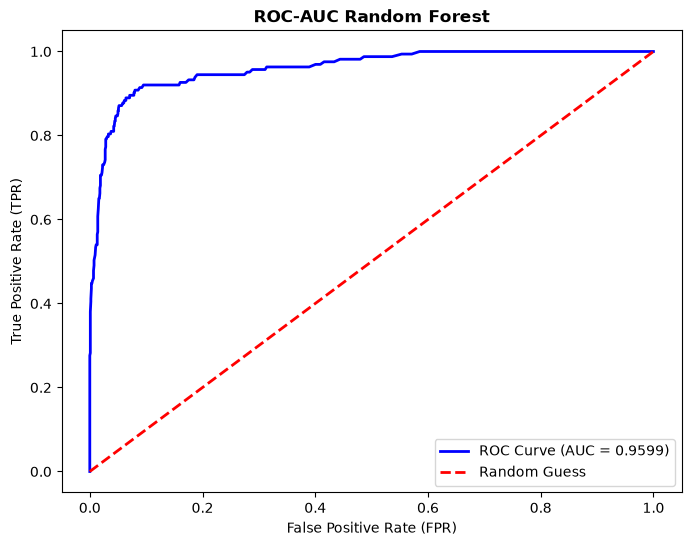

In [284]:
fpr_clf_rf, tpr_clf_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_clf_rf)

# Visualisasi kurva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_clf_rf, tpr_clf_rf, color='blue', lw=2, label=f'ROC Curve (AUC = {roc_auc_clf_rf:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-AUC Random Forest', fontweight='bold')
plt.legend(loc='lower right')
plt.savefig('ROC-AUC_RF_dengan_HYP.png', dpi=400)
plt.show()

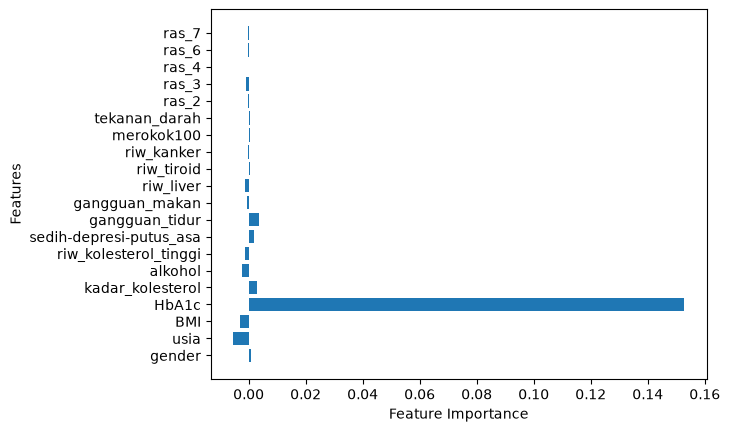

In [285]:
from sklearn.inspection import permutation_importance
result_rf = permutation_importance(clf_rf, X_test, y_test, n_repeats=10, random_state=42)
importance_rf = result_rf.importances_mean
#visualisasi
import matplotlib.pyplot as plt
plt.barh(X_train.columns, importance_rf)
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.show()

## 6. Feature Importance

In [286]:
from eli5.sklearn import PermutationImportance

### 6.1 KNN

In [287]:
# Untuk model KNN
perm_clf_knn = PermutationImportance(clf_knn, random_state=42).fit(X_test, y_test)
eli5.show_weights(perm_clf_knn, feature_names=X_test.columns.tolist())

Weight,Feature
0.0297 ± 0.0185,riw_kolesterol_tinggi
0.0170 ± 0.0055,HbA1c
0.0168 ± 0.0071,usia
0.0162 ± 0.0091,alkohol
0.0112 ± 0.0064,merokok100
0.0075 ± 0.0047,BMI
0.0032 ± 0.0062,gangguan_tidur
0.0029 ± 0.0047,sedih-depresi-putus_asa
0.0029 ± 0.0070,tekanan_darah
0.0025 ± 0.0068,gangguan_makan


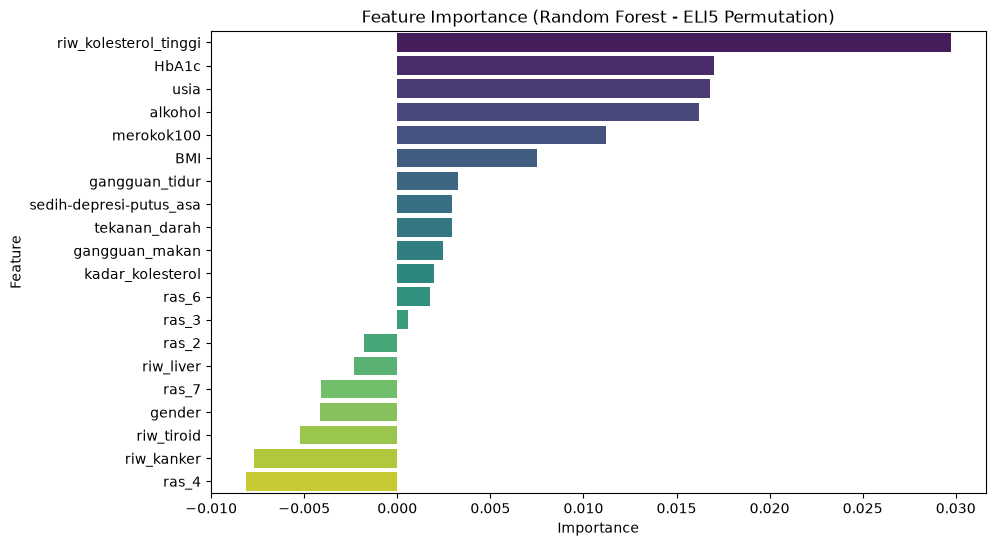

In [288]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

clf_knn_importance_values = perm_clf_knn.feature_importances_
feature_names = X_test.columns

clf_knn_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': clf_knn_importance_values})
clf_knn_importance_df = clf_knn_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=clf_knn_importance_df, palette='viridis')
plt.title('Feature Importance (Random Forest - ELI5 Permutation)')
# plt.tight_layout()
plt.show()

### 6.2 XGBoost

In [289]:
# Untuk model SVM
perm_clf_xgb = PermutationImportance(clf_xgb, random_state=42).fit(X_test, y_test)
eli5.show_weights(perm_clf_xgb, feature_names=X_test.columns.tolist())

Weight,Feature
0.1429 ± 0.0109,HbA1c
0.0112 ± 0.0029,kadar_kolesterol
0.0041 ± 0.0035,merokok100
0.0035 ± 0.0038,ras_3
0.0033 ± 0.0039,riw_kolesterol_tinggi
0.0028 ± 0.0028,gangguan_tidur
0.0011 ± 0.0012,ras_7
0.0009 ± 0.0025,tekanan_darah
0.0009 ± 0.0000,ras_2
0.0003 ± 0.0026,gangguan_makan


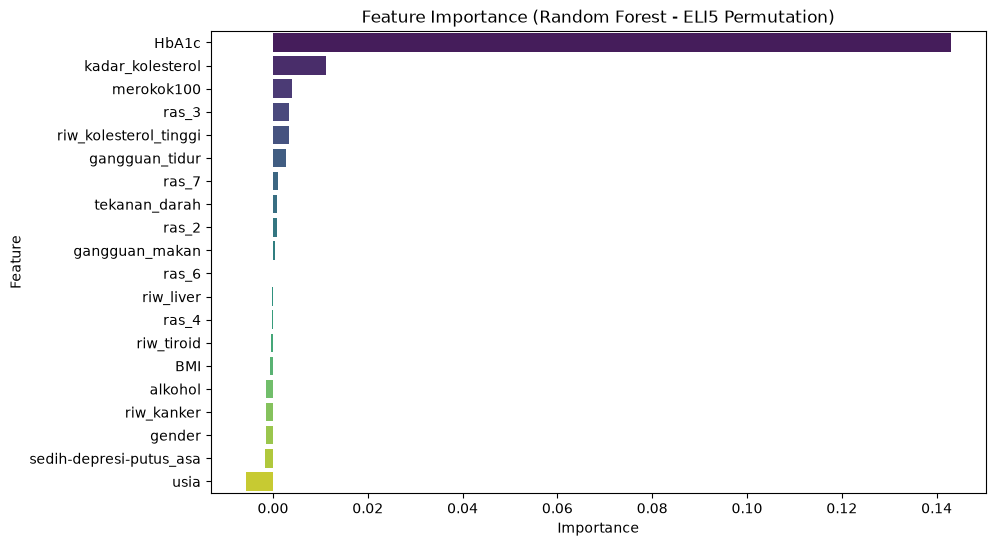

In [290]:
clf_xgb_importance_values = perm_clf_xgb.feature_importances_
feature_names = X_test.columns

clf_xgb_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': clf_xgb_importance_values})
clf_xgb_importance_df = clf_xgb_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=clf_xgb_importance_df, palette='viridis')
plt.title('Feature Importance (Random Forest - ELI5 Permutation)')
# plt.tight_layout()
plt.show()

### 6.3 SVM

In [291]:
# Untuk model Random Forest
perm_clf_svm = PermutationImportance(clf_svm, random_state=42).fit(X_test, y_test)
eli5.show_weights(perm_clf_svm, feature_names=X_test.columns.tolist())

Weight,Feature
0.0915 ± 0.0157,HbA1c
0.0160 ± 0.0104,kadar_kolesterol
0.0107 ± 0.0118,riw_kolesterol_tinggi
0.0095 ± 0.0026,usia
0.0091 ± 0.0029,ras_3
0.0054 ± 0.0107,merokok100
0.0046 ± 0.0051,ras_7
0.0045 ± 0.0056,gangguan_tidur
0.0044 ± 0.0061,BMI
0.0044 ± 0.0064,alkohol


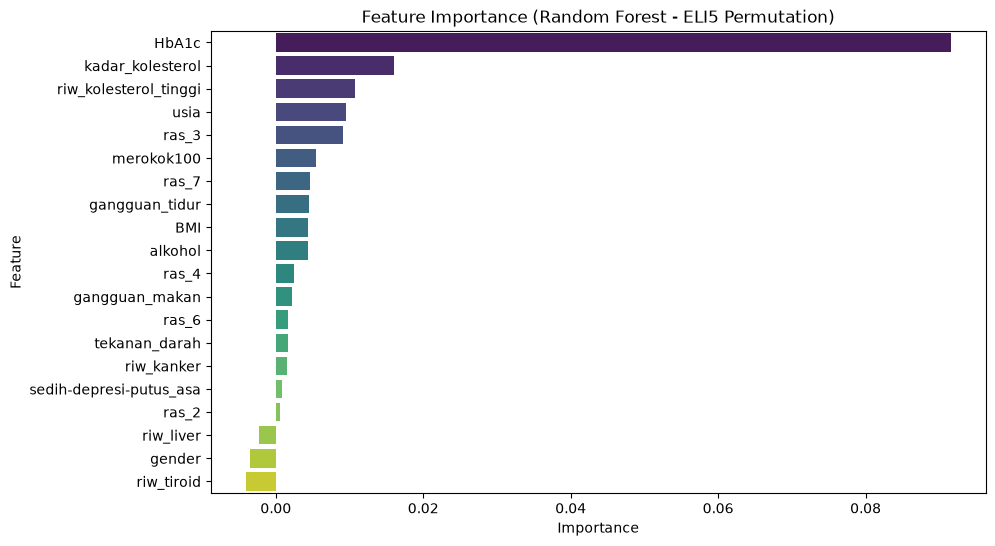

In [292]:
clf_svm_importance_values = perm_clf_svm.feature_importances_
feature_names = X_test.columns

clf_svm_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': clf_svm_importance_values})
clf_svm_importance_df = clf_svm_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=clf_svm_importance_df, palette='viridis')
plt.title('Feature Importance (Random Forest - ELI5 Permutation)')
# plt.tight_layout()
plt.show()

### 6.4 Random Forest

In [293]:
# Untuk model XGBoost (pastikan input-nya sudah sesuai)
perm_clf_rf = PermutationImportance(clf_rf, random_state=42).fit(X_test, y_test)
eli5.show_weights(perm_clf_rf, feature_names=X_test.columns.tolist())

Weight,Feature
0.1473 ± 0.0148,HbA1c
0.0050 ± 0.0046,kadar_kolesterol
0.0037 ± 0.0043,gangguan_tidur
0.0010 ± 0.0019,sedih-depresi-putus_asa
0.0009 ± 0.0014,merokok100
0.0009 ± 0.0018,gender
0.0007 ± 0.0019,ras_4
0.0004 ± 0.0020,riw_tiroid
0.0003 ± 0.0030,riw_kolesterol_tinggi
0.0002 ± 0.0012,ras_6


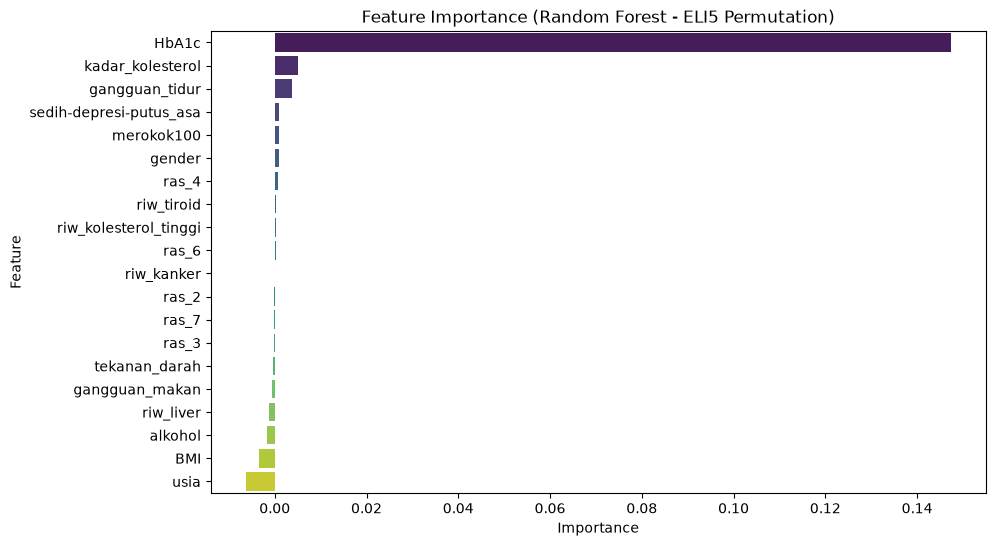

In [294]:
clf_rf_importance_values = perm_clf_rf.feature_importances_
feature_names = X_test.columns

clf_rf_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': clf_rf_importance_values})
clf_rf_importance_df = clf_rf_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', hue='Feature', data=clf_rf_importance_df, palette='viridis')
plt.title('Feature Importance (Random Forest - ELI5 Permutation)')
# plt.tight_layout()
plt.show()

## 7. Export Model

### 7.1 XGBoost

In [295]:
import pickle

In [297]:
with open('../pkl/clf_xgb.pkl', 'wb') as file:
    pickle.dump(clf_xgb, file)

### 7.2 Random Forest

In [298]:
with open('../pkl/clf_rf.pkl', 'wb') as file:
    pickle.dump(clf_rf, file)